_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: Luca Kosina, Sascha Mühlinghaus, Max Bardelang

LLM Disclaimer: ChatGPT for help with data analysis, Perplexity for literature search and Copilot for repetitive code tasks.

# Neural Data Science Project 01

## Working with Calcium data

In the following project you will recieve a data set, along with a set of questions. Use the methods that you have learned throughout this course to explore the data and to answer the questions. You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

## Context
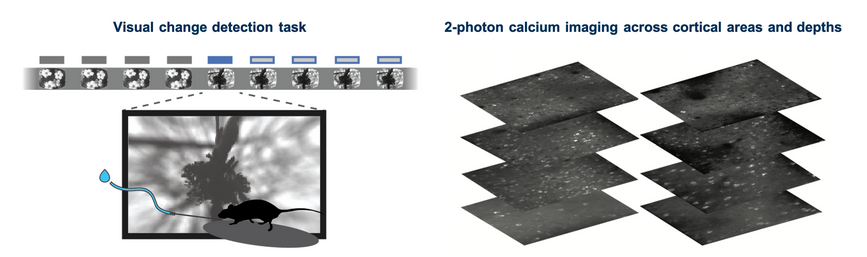

The data set that goes along with this notebook was recorded using in vivo 2-photon calcium imaging to measure the activity of genetically identified neurons in the visual cortex of mice performing a go/no-go visual change detection task. The data recordings stem from primary visual cortex and a GCaMP6f indicator was used. The data was recorded as follows.

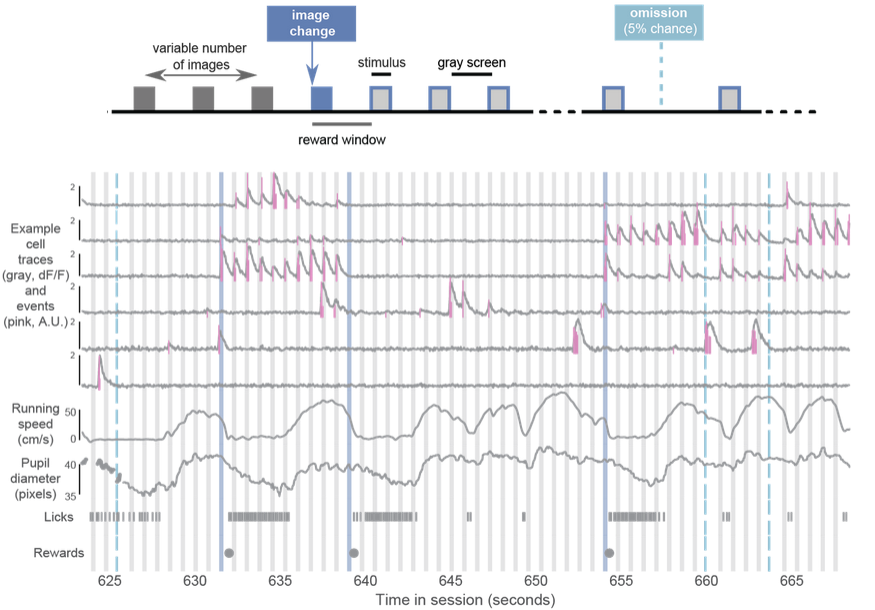

The data consists of:
- the preprocessed activity traces (df/f)
- the stimulus metadata
- the ROI masks for each cell
- a maximum activity projection of the recorded area
- running speed
- table of stimulus epochs

You will only work with a drifting grating stimulus.

Since the experiments were performed in sequence the calcium recordings that you receive also contain some other stimulus modalities (see `data["stim_epoch_table"]`). You can ignore these sections of the time-series data during analysis. Not all the data provided has to be used, however it can be incorporated into your analysis.

In [ ]:
# import packages here

import numpy as np
import pandas as pd
import jupyter_black
from scipy import signal
from scipy.signal import butter, filtfilt
from scipy import optimize as opt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks
import scipy.stats as stats
import scipy.optimize as opt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import hsv_to_rgb, Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import random

jupyter_black.load()
from typing import Tuple

from joblib import Parallel, delayed

# from tqdm import tqdm
import time
import oopsi

# from oasis.functions import (
#     gen_data,
#     gen_sinusoidal_data,
#     deconvolve,
#     estimate_parameters,
# )
# from oasis.plotting import simpleaxis
# from oasis.oasis_methods import oasisAR1, oasisAR2

In [ ]:
# load data
def load_data(path="."):
    def array2df(d, key, cols):
        d[key] = pd.DataFrame(d[key], columns=cols)

    data = np.load(path + "/dff_data_dsi.npz", allow_pickle=True)
    data = dict(data)
    array2df(
        data,
        "stim_table",
        ["frequency", "direction", "blank_sweep", "start", "end"],
    )
    array2df(data, "stim_epoch_table", ["stimulus", "start", "end"])

    return data


def print_info(data):
    data_iter = ((k, type(v), v.shape) for k, v in data.items())
    l = [f"[{k}] - {t}, - {s}" for k, t, s in data_iter]
    print("\n".join(l) + "\n")


data = load_data(path="../data/project-01")  # adjust the path as necessary

print("Overview of the data")
print_info(data)

Overview of the data
[t] - <class 'numpy.ndarray'>, - (115471,)
[dff] - <class 'numpy.ndarray'>, - (106, 115471)
[stim_table] - <class 'pandas.core.frame.DataFrame'>, - (628, 5)
[roi_masks] - <class 'numpy.ndarray'>, - (106, 512, 512)
[max_projection] - <class 'numpy.ndarray'>, - (512, 512)
[running_speed] - <class 'numpy.ndarray'>, - (2, 115471)
[stim_epoch_table] - <class 'pandas.core.frame.DataFrame'>, - (7, 3)



## Question

**Is there spatial structure in the preferred orientation/direction/frequency?**

Implement all steps of the processing pipeline that are necessary to answer them. Think of:
1. Pre-processing
2. Spike inference
3. Tuning function fitting
4. Statistical testing.

It is sufficient to assess spatial structure visually. Additional insights and analyses will be positively factored into the overall grade.

# Implementation

We are following these steps to answer the questions:

We first segement the data into trials and the pre-processe it by applying a filter, normalizing it and smoothing the data. We then compare to different methods to infer spikes: OOPSI and OASIS. 
We then fit tuning curves to the detected spikes after stimulus presentation and by permutation analysis check which neurons have certain orientation, direction and frequency preference.
Then using the mask we plot the entire filed of neurons with their respective preference to check if we can visually see an organization of the neurons into columns.



#### Outline of the notebook:
0. Import libraries/Load data 
1. Preprocess data
    - Data exploration
    - Segment data into trials
    - Filter and normalize data
    - Smooth data
2. Spike inference
   - OOPSI
   - OASIS
3. Tuning function fitting
   - Fit tuning curves for orientation, direction, and frequency
   - Permutation testing for significance
4. Spatial structure analysis
   - Visualize spatial structure of neurons
   - Correlate spatial structure with tuning properties
5. Conclusion

## 1 Pre-processing

In [ ]:
# plot the dff data for a given neuron
neuron = 0
dff = data["dff"]
t = data["t"]
stim = data["stim_table"]
stim_epoch = data["stim_epoch_table"]

### 1.1 selection drifting_gratings data

The experiments consits of epochs with different stimuli. `stim_epoch_table` contains start and end frame of each epoch. Since were interested only in the `drifting_gratings`, we cut out this data:

In [ ]:
# convert stim epoch start and end column to integers
stim_epoch["start"] = stim_epoch["start"].astype(int)
stim_epoch["end"] = stim_epoch["end"].astype(int)
stim_epoch

,stimulus,start,end
0,drifting_gratings,747,18775
1,natural_movie_three,19709,37767
2,natural_movie_one,38671,47699
3,drifting_gratings,48602,66630
4,spontaneous,66780,75697
5,natural_movie_three,75698,93756
6,drifting_gratings,94659,115215


Throughout the analysis, we will work with a DataFrame to handle data

In [ ]:
df = pd.DataFrame(dff.T)
df.columns.name = "neuron"
df.index.name = "frame"

# cut out drifting gratings epochs
drifting_epochs = stim_epoch[stim_epoch["stimulus"] == "drifting_gratings"].reset_index(
    drop=True
)

records = []
for i, row in drifting_epochs.iterrows():
    epoch_df = df.loc[row.start : row.end, :]
    # add epoch number as column index
    epoch_df.index = pd.MultiIndex.from_product(
        [[i], epoch_df.index], names=["epoch", "frame"]
    )
    records.append(epoch_df)

df_raw = pd.concat(records, axis=0)
df_raw

neuron             0         1         2         3         4         5    \
epoch frame                                                                
0     747     0.059512 -0.063161 -0.019814 -0.064979  0.067324  0.021476   
      748    -0.000203 -0.049975  0.030449  0.041945  0.006195 -0.014444   
      749    -0.041120 -0.068027  0.055002 -0.067749 -0.005289 -0.046250   
      750    -0.098806  0.074266 -0.006529  0.006800  0.031468  0.046876   
      751    -0.028460  0.028866  0.051883  0.115626  0.001330  0.075100   
...                ...       ...       ...       ...       ...       ...   
2     115211 -0.012725  0.011566  0.043530  0.018481 -0.075041  0.010294   
      115212 -0.012888  0.003882  0.037825 -0.063592 -0.007616  0.039843   
      115213  0.044822 -0.022734 -0.016276 -0.086995 -0.020194  0.031156   
      115214 -0.055499 -0.053176 -0.048795 -0.084779 -0.009320  0.068994   
      115215 -0.109390 -0.006519 -0.077936 -0.056792 -0.002331 -0.035282   

neuron             6         7         8         9    ...       96        97   \
epoch frame                                           ...                       
0     747    -0.025787 -0.000141 -0.006664  0.036956  ... -0.043115 -0.005537   
      748    -0.008338  0.031437  0.049524 -0.037182  ...  0.033092  0.003726   
      749    -0.029259  0.101742 -0.025278 -0.051245  ...  0.004700  0.035787   
      750     0.001280  0.008053  0.017523 -0.021524  ...  0.134587 -0.001434   
      751     0.028452 -0.049464  0.017742  0.041560  ...  0.048615  0.008920   
...                ...       ...       ...       ...  ...       ...       ...   
2     115211  0.042833  0.066424  0.898020 -0.021838  ...  0.024481  0.041598   
      115212 -0.028717 -0.042497  1.191723 -0.051500  ... -0.069082  0.071589   
      115213 -0.014092  0.032496  1.026063  0.034322  ...  0.012087  0.132241   
      115214 -0.072743 -0.098667  0.824707  0.031996  ... -0.022002  0.036148   
      115215 -0.036401 -0.003220  0.890062  0.022936  ... -0.037532  0.062050   

neuron             98        99        100       101       102       103  \
epoch frame                                                                
0     747    -0.001483  0.153535 -0.008959  0.014240  0.085813 -0.066683   
      748     0.068913  0.086297 -0.010431 -0.006715  0.055087 -0.052482   
      749    -0.012316  0.001702  0.012815  0.050914  0.083215  0.037526   
      750     0.026124 -0.091168 -0.010381  0.124242 -0.003417  0.056991   
      751     0.071050  0.019964  0.102945  0.093136  0.005253  0.023856   
...                ...       ...       ...       ...       ...       ...   
2     115211  0.021203  0.112598  0.065437 -0.012071 -0.021133 -0.037243   
      115212 -0.035257  0.040120  0.061543 -0.072416 -0.005645  0.014365   
      115213 -0.005524  0.031642 -0.005066  0.048101 -0.041793 -0.017129   
      115214 -0.013789 -0.022765 -0.005168 -0.026585  0.003097 -0.021029   
      115215  0.051854  0.094462 -0.049081  0.000000 -0.024927  0.000970   

neuron             104       105  
epoch frame                       
0     747     0.046780  0.036651  
      748     0.187832  0.028809  
      749     0.100032  0.009712  
      750     0.168290  0.026584  
      751     0.035082  0.137172  
...                ...       ...  
2     115211 -0.053058 -0.018237  
      115212 -0.014696 -0.000033  
      115213  0.006574 -0.077658  
      115214 -0.017389  0.000000  
      115215 -0.068638 -0.009105  

[56615 rows x 106 columns]

### 1.2 Data Exploration

We start by looking at the epochs of a few randomly selected neurons

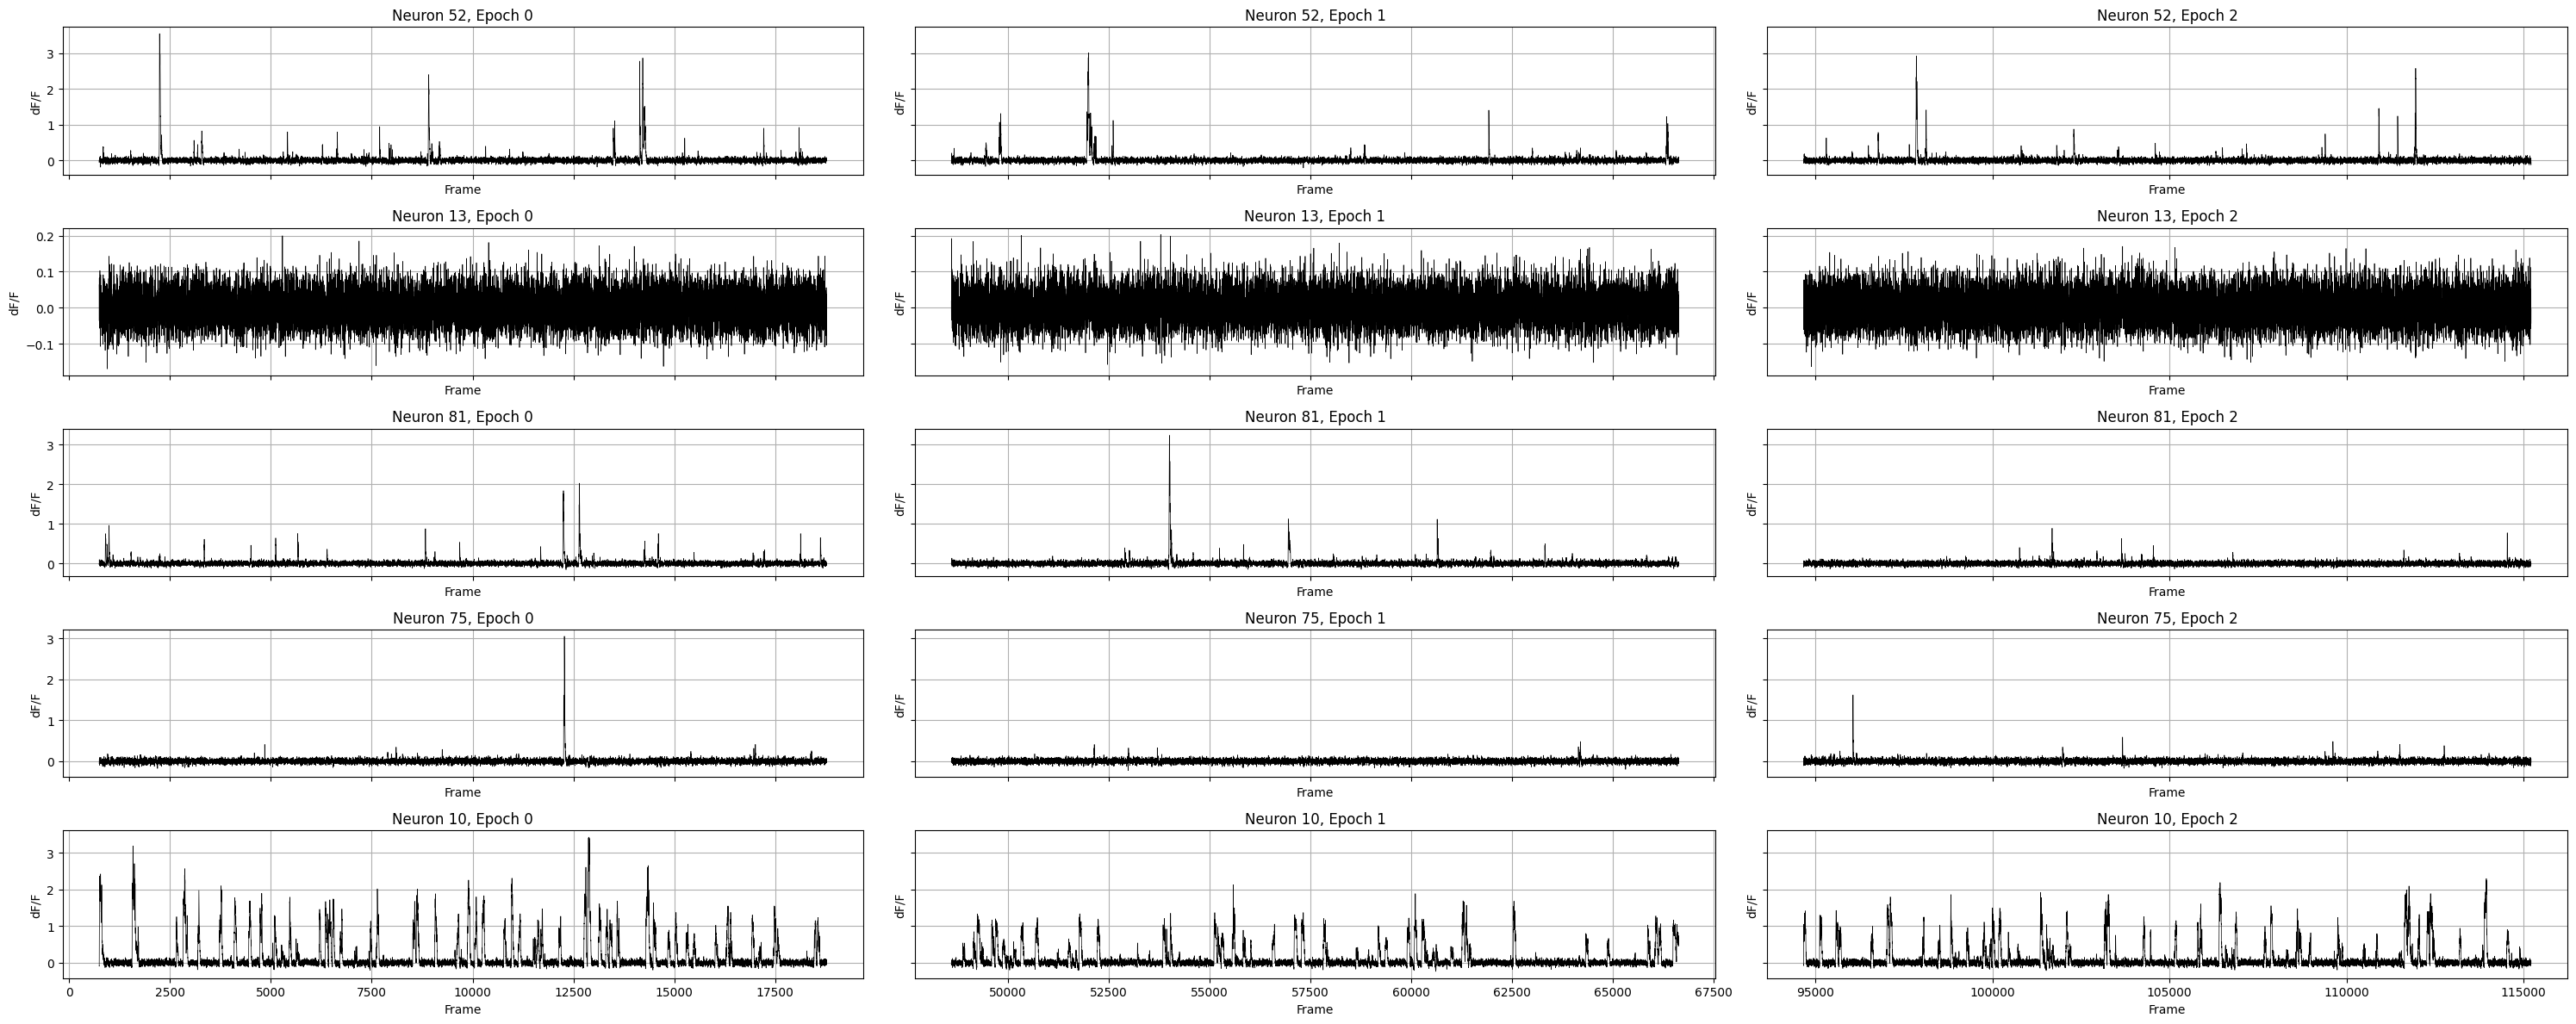

In [ ]:
# randomly select a few neurons to plot
n_neurons = 5
neurons = random.sample(list(df_raw.columns), n_neurons)
# plot the epochs of the selected neurons
fig, axes = plt.subplots(n_neurons, 3, figsize=(30, 12), sharex="col", sharey="row")

# plot all 3 epochs of each selected neuron in one row
for i, neuron in enumerate(neurons):
    for j, epoch in enumerate(range(3)):
        ax = axes[i, j]
        epoch_df = df_raw.xs(epoch, level="epoch")
        ax.plot(epoch_df.index, epoch_df[neuron], color="black", lw=0.5)
        ax.set_title(f"Neuron {neuron}, Epoch {epoch}")
        ax.set_xlabel("Frame")
        ax.set_ylabel("dF/F")
        ax.grid(True)
fig.tight_layout()

Let's look at the first drifting gratings stimulus epoch for the first neuron in the dataset. We will plot the dF/F data for this neuron over time.

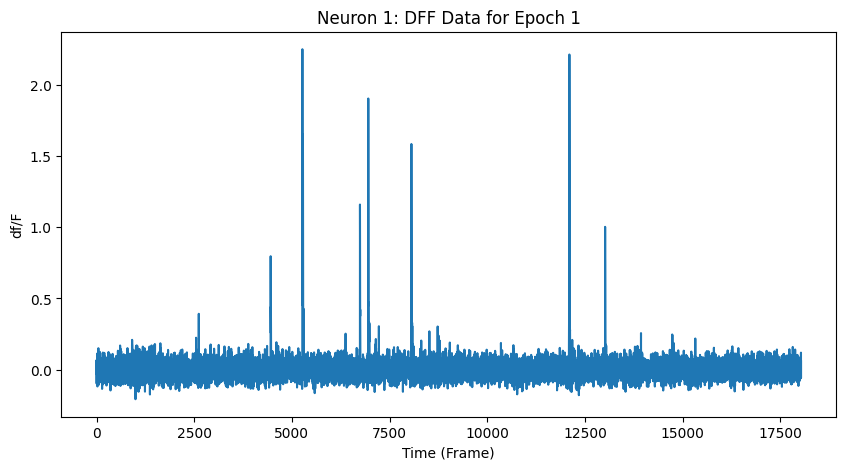

In [ ]:
# Epoch 1: drifting grating stimulus [747, 18775]

start, end = data["stim_epoch_table"].iloc[0][["start", "end"]]
neuron = 0  # Specify the neuron index to plot
plt.figure(figsize=(10, 5))
plt.plot(
    dff[neuron][start:end],
    label=f"Neuron {neuron} - Epoch 1",
)
plt.title("Neuron 1: DFF Data for Epoch 1")
plt.xlabel("Time (Frame)")
plt.ylabel("df/F");

In [ ]:
# out of curiosity, we also look at the running speed of the recorded animal
running_speed = data["running_speed"][1]
running_speed

array([   9.67741,    9.71067,    9.74392, ..., 3849.55347, 3849.58673,
       3849.61999])

We wonder if the running speed has an effect on the calcium signal. We will plot the running speed and the dF/F data for the first neuron in the dataset.

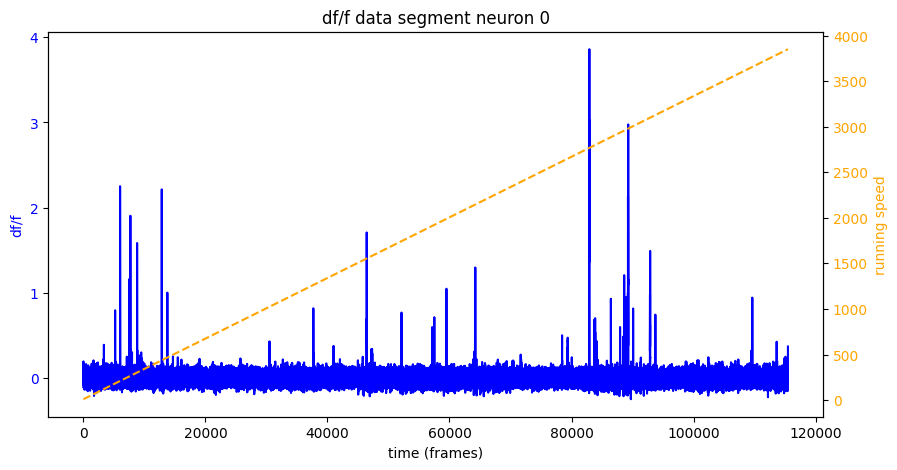

In [ ]:
# extract stimulus trial for the example neuron
stim_trial = data["stim_table"].iloc[0]  # first stimulus trial
start, end = data["stim_epoch_table"].iloc[0][["start", "end"]]

# create first y-axis for df/f
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(data["dff"][0], label="neuron 0", color="blue")
ax1.set_xlabel("time (frames)")
ax1.set_ylabel("df/f", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# create second y-axis for running speed
ax2 = ax1.twinx()
ax2.plot(running_speed, label="running speed", color="orange", linestyle="--")
ax2.set_ylabel("running speed", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# add title and show plot
plt.title("df/f data segment neuron 0")
plt.show()

It is interesting to see that the running speed is strictly increasing over time as a linear function with constant slope. From visual inspection we cannot identify any trend related to the running speed of the mice. We are quite surprised about the little variation in the running speed. We assume that this cannot be integrated into our analysis. To see more of the frequency structure let´s look at a specific segment of the data:

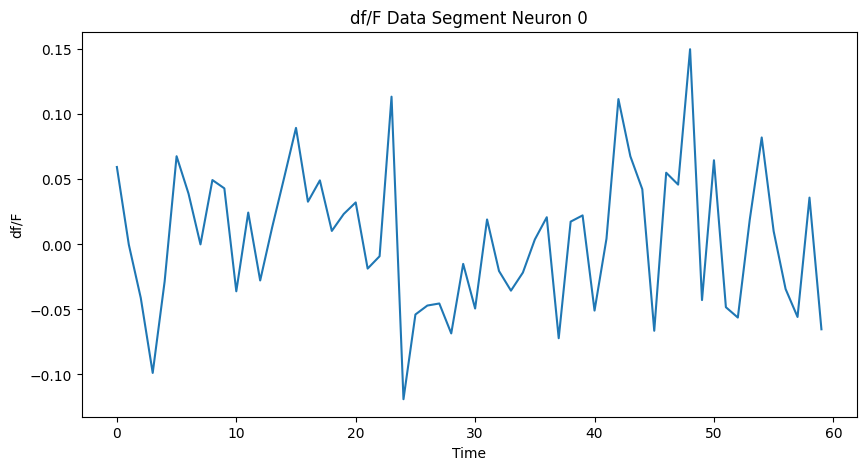

In [ ]:
# look at specific trial / segment of the data for the example neuron
plt.figure(figsize=(10, 5))

# extract stimulus trial for the example neuron
stim_trial = data["stim_table"].iloc[0]  # First stimulus trial
start, end = int(stim_trial["start"]), int(stim_trial["end"])

plt.plot(
    data["dff"][0][start:end],
    label="Neuron 0",
)
plt.title("df/F Data Segment Neuron 0")
plt.xlabel("Time")
plt.ylabel("df/F")
plt.show()

When inspecting multiple neurons, we also see a lot of variance across them. Hence, the data is not normalized and to be able to better detect artefacts like spikes we need to highpass filter, smooth and normalize the data. In the following we will look more closely at how the epochs and trials are structured in the data. Each trial is about 60 frames long but sometimes also a bit longer or shorter. We also see that the epochs have diferent lengths.

In [ ]:
# get length of trials by
trial_length = np.array([row.end - row.start for _, row in stim.iterrows()])
print(f"Unique trial lengths: {np.unique(trial_length)}")

Unique trial lengths: [59. 60. 61.]


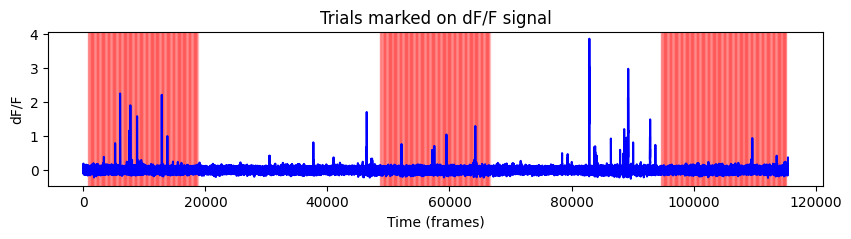

In [ ]:
def mark_trials(ax, stim_table, color="red", alpha=0.5):
    for _, row in stim_table.iterrows():
        ax.axvspan(row.start, row.end, color=color, alpha=alpha)


fig, ax = plt.subplots(figsize=(10, 2))
mark_trials(ax, stim, color="red", alpha=0.2)
ax.plot(dff[neuron], label=f"Neuron {neuron}", color="blue")
ax.set_xlabel("Time (frames)")
ax.set_ylabel("dF/F")
ax.set_title("Trials marked on dF/F signal")
plt.show()

For the sake of simplicity we will put the trials and epochs into a single dataframe.

In [ ]:
# estimate the sampling frequency
dt = np.mean(np.diff(data["t"]))
print("dt:", dt)
fs = np.round(1 / dt)
print("fs:", fs)
cut_off = 0.5  # cutoff frequency for the filter
print("cut_off:", cut_off)

dt: 0.03325489373863341
fs: 30.0
cut_off: 0.5


### 1.3 Filtering, Normalization and Smoothing

We have seen that there are a lot of high frequency components in the data which we want to filter out to be able to improve spike detection. We use a butter bandpass filter to avoid introducing phase shifts.

The smoothing has been adapted from [Yaksi and Friedrich (2006)](https://pubmed.ncbi.nlm.nih.gov/16628208/) and the normalization and filtering is based on the methods of [Vogelstein et al. (2020)](https://pubmed.ncbi.nlm.nih.gov/20554834/). The steps are as follows:
1. **Filtering**: Highpass filtering to get rid of any slow drifts that occur over long time-spans.
2. **Normalization**: The filtered signals are then normalized to have a consistent baseline, which is crucial for comparing activity across different neurons and epochs.
3. **Smoothing**: Finally, we apply a smoothing algorithm to reduce high-frequency noise and artifacts, ensuring that the extracted signals more accurately reflect the underlying neural activity.

A note on the filtering: At first we applied a low-pass and band-pass filter to the data, but we found that the spike detection was very arbitrary and not very reliable. After some testing we found that a high-pass filter with a cutoff frequency of 0.5 Hz works best for our data. The preprocessing was a lot of trial and error, eventually we followed the methods of [Vogelstein et al. (2020)](https://pubmed.ncbi.nlm.nih.gov/20554834/) and [Yaksi and Friedrich (2006)](https://pubmed.ncbi.nlm.nih.gov/16628208/) to preprocess the data.

In [ ]:
def highpass_filter(group, fs=30, cutoff=0.5):
    """
    Apply highpass filter to each trace in the group.

    Parameters:
    - group: DataFrame with trace
    - fs: sampling frequency (Hz)
    - cutoff: cutoff frequency (Hz)

    Returns: DataFrame with filtered traces
    """
    nyq = 0.5 * fs
    # normalize the cutoff frequency
    normal_cutoff = cutoff / nyq
    b, a = butter(4, normal_cutoff, btype="low", analog=False)
    filtered = filtfilt(b, a, group.values)
    return pd.Series(filtered, index=group.index.get_level_values("frame"))


def normalize_trace(group):
    """Normalize the trace to the range [0, 1].

    Parameters:
    - group: DataFrame with trace
    """

    f_min = group.values.min()
    f_max = group.values.max()
    return pd.Series(
        (group.values - f_min) / (f_max - f_min),
        index=group.index.get_level_values("frame"),
    )


def smooth_trace(group, thr_noise=1.0, max_iter=5000):
    """
    smooth the trace using iterative local averaging based on peak amplitude differences

    parameters:
    - group: series with calcium trace (df/f values)
    - thr_noise: noise threshold for peak amplitude differences
    - max_iter: maximum number of smoothing iterations

    returns:
    - smoothed trace as a pandas series with same index as input
    """
    trace = group.values.copy()
    smoothed = trace.copy()
    iteration = 0

    while iteration < max_iter:
        peaks, _ = find_peaks(smoothed)
        if len(peaks) < 2:
            break

        amp_diffs = np.diff(smoothed[peaks])
        amp_diffs = np.insert(amp_diffs, 0, np.inf)
        pmin_idx = np.argmin(np.abs(amp_diffs))

        if abs(amp_diffs[pmin_idx]) >= thr_noise:
            break

        if pmin_idx == 0 or pmin_idx == len(peaks) - 1:
            break

        start = peaks[pmin_idx - 1]
        end = peaks[pmin_idx + 1]

        segment = smoothed[start : end + 1].copy()
        for _ in range(3):
            segment[1:-1] = (segment[:-2] + segment[1:-1] + segment[2:]) / 3

        smoothed[start : end + 1] = segment
        iteration += 1

    return pd.Series(smoothed, index=group.index.get_level_values("frame"))

PLACEHOLDER: explain and cite highpass filering and normalization.  

#### Smoothing adapted from [Yaksi and Friedrich (2006)](https://pubmed.ncbi.nlm.nih.gov/16628208/)
The smoothing procedure iteratively reduces noise in the calcium signal by identifying and locally averaging low-amplitude peaks that are likely noise. In each iteration, the smallest peak (below a noise threshold) is smoothed by averaging it with neighboring values. This process repeats until all such peaks are addressed, no further change occurs, or a max iteration limit is reached. The method effectively removes noise while preserving true signal features, improving the accuracy of subsequent deconvolution without degrading temporal resolution.

In [ ]:
df_preprocessed = (
    df_raw.stack("neuron")
    .groupby(["neuron", "epoch"])
    .apply(highpass_filter, fs=30, cutoff=0.5)
    .groupby(["neuron", "epoch"])
    .apply(normalize_trace)
    .groupby(["neuron", "epoch"])
    .apply(smooth_trace)
    .unstack("neuron")
)
df_preprocessed.reset_index(inplace=False)
df_preprocessed

neuron             0         1         2         3         4         5    \
epoch frame                                                                
0     747     0.205041  0.000000  0.201189  0.000000  0.233279  0.136643   
      748     0.203099  0.013988  0.207664  0.083451  0.226652  0.136581   
      749     0.201018  0.029092  0.214076  0.164982  0.219969  0.136485   
      750     0.198810  0.045323  0.220386  0.244210  0.213259  0.136357   
      751     0.196490  0.062691  0.226558  0.320767  0.206552  0.136196   
...                ...       ...       ...       ...       ...       ...   
2     115211  0.105004  0.751521  0.211653  0.191105  0.249700  0.416030   
      115212  0.102587  0.753420  0.210046  0.188176  0.249458  0.414285   
      115213  0.100458  0.754911  0.208609  0.185596  0.249243  0.412750   
      115214  0.098608  0.756056  0.207341  0.183355  0.249056  0.411419   
      115215  0.097025  0.756914  0.206241  0.181439  0.248895  0.410285   

neuron             6         7         8         9    ...       96        97   \
epoch frame                                           ...                       
0     747     0.018682  0.322033  0.082538  0.200014  ...  0.233229  0.118694   
      748     0.047830  0.323275  0.082832  0.192659  ...  0.234341  0.120671   
      749     0.076337  0.324388  0.083138  0.185596  ...  0.235668  0.122686   
      750     0.104067  0.325378  0.083456  0.178846  ...  0.237190  0.124733   
      751     0.130897  0.326253  0.083781  0.172430  ...  0.238891  0.126809   
...                ...       ...       ...       ...  ...       ...       ...   
2     115211  0.181564  0.311854  0.623758  0.296327  ...  0.119356  0.271637   
      115212  0.179029  0.310743  0.628029  0.296992  ...  0.119191  0.272657   
      115213  0.176845  0.309815  0.631623  0.297558  ...  0.119042  0.273516   
      115214  0.174989  0.309051  0.634601  0.298033  ...  0.118910  0.274228   
      115215  0.173436  0.308434  0.637030  0.298425  ...  0.118795  0.274809   

neuron             98        99        100       101       102       103  \
epoch frame                                                                
0     747     0.130797  0.738727  0.153955  0.308356  0.593111  0.000000   
      748     0.135532  0.698372  0.156253  0.310692  0.573582  0.045764   
      749     0.140065  0.658536  0.158496  0.312839  0.554248  0.090861   
      750     0.144377  0.619374  0.160670  0.314761  0.535201  0.135096   
      751     0.148452  0.581034  0.162761  0.316420  0.516527  0.178283   
...                ...       ...       ...       ...       ...       ...   
2     115211  0.184942  0.423950  0.057382  0.228786  0.116550  0.445820   
      115212  0.185161  0.426335  0.057227  0.228633  0.116441  0.446283   
      115213  0.185360  0.428406  0.057083  0.228490  0.116342  0.446679   
      115214  0.185540  0.430179  0.056951  0.228359  0.116253  0.447013   
      115215  0.185698  0.431674  0.056833  0.228242  0.116174  0.447291   

neuron             104       105  
epoch frame                       
0     747     0.192719  0.599603  
      748     0.192648  0.607922  
      749     0.192511  0.616153  
      750     0.192308  0.624205  
      751     0.192039  0.631981  
...                ...       ...  
2     115211  0.112896  0.249596  
      115212  0.112401  0.249396  
      115213  0.111980  0.249241  
      115214  0.111625  0.249123  
      115215  0.111330  0.249036  

[56615 rows x 106 columns]

Text(0.5, 0.98, 'Inspect preprocessed and raw data')

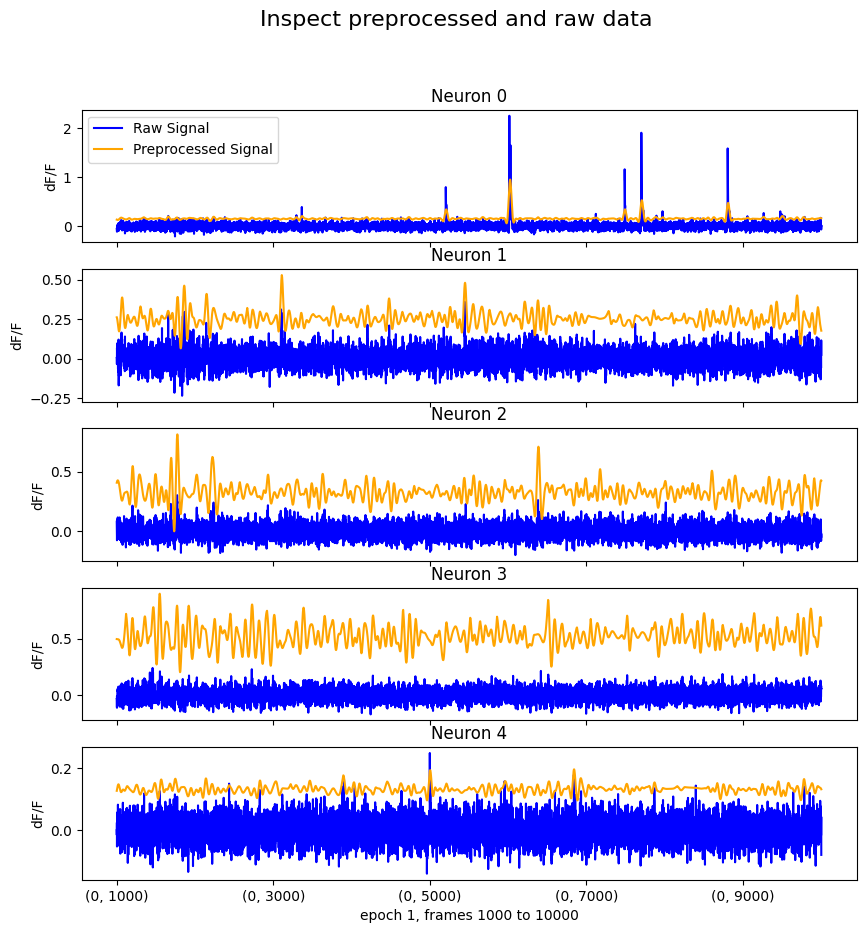

In [ ]:
# plot raw and filtered signal epoch 1 of neurons 0-4
neuron_indices = range(0, 5)  # Neuron indices to plot
interval = slice(1000, 10000)  # Interval to plot
fig, axes = plt.subplots(len(neuron_indices), 1, figsize=(10, 10), sharex=True)

for i, neuron in enumerate(neuron_indices):
    ax = axes[i]
    df_raw.loc[(0, interval), neuron].plot(ax=ax, label="Raw Signal", color="blue")
    df_preprocessed.loc[(0, interval), neuron].plot(
        ax=ax, label="Preprocessed Signal", color="orange"
    )
    ax.set_title(f"Neuron {neuron}")
    ax.set_ylabel("dF/F")
    ax.set_xlabel(f"epoch 1, frames {interval.start} to {interval.stop}")
    if i == 0:
        ax.legend()

# set title for the entire figure
fig.suptitle("Inspect preprocessed and raw data", fontsize=16)

The preprocessing of the data is important for the subsequent analysis steps, as it removes noise and frequencies that interfere with the signals being clean and ready for spike inference and tuning function fitting.

## 2 Spike Inference

We will use two different methods to infer spikes: The "optimal optical spike inference" (oopsi) algorithm from
Vogelstein (2009) (https://www.proquest.com/openview/848560ad7b34bed24b815fd2d006d089/1?pq-origsite=gscholar&cbl=18750) and the Fast online deconvolution algorithm for AR1 processes with positive jumps from Friedrich J, Paninski L. Fast Active Set Method for Online Spike Inference from Calcium Imaging. In: Adv Neural Inf Process Syst. 2016; p. 1984–1992 (https://github.com/j-friedrich/OASIS). 

These methods are inferring spike times from the calcium trace differently which is why we want to compare their performance. OOPSI does spike convolution, i.e. the fluorescene signal is an approximate convolution of the spikes with the calcium response. Oopsi gives us values between 0 and 1 for the spiking probability which we will then add up to approximate a spike count. 

OASIS has an optimization problem approach to inference of spikes. Therefore it takes the calcium data, the decay factor g and a regularization parameter lambda as input parameters.

### 2.1 Spike Inference with OOPSI

In [ ]:
def apply_oopsi(group, dt=1 / 30):
    """
    apply oopsi deconvolution to a trace group and return results as pd.Series

    parameters:
    - group: pd.Series (dF/F values for one neuron × epoch)
    - dt: time step in seconds

    returns:
    - pd.Series with spike train (n) indexed by frame
    """
    trace = group.values.astype(np.float64)
    n, _ = oopsi.fast(trace, dt=dt, iter_max=100, update=True)
    return pd.Series(n, index=group.index)


def apply_oopsi_parallel(df, dt=1 / 30, n_jobs=4):
    """
    parallel apply of oopsi deconvolution across neuron × epoch groups

    parameters:
    - df: multi-index dataframe (epoch, frame) × neuron
    - dt: time step (default 1/30 for 30 Hz)
    - n_jobs: number of parallel jobs

    returns:
    - dataframe with spike estimates (same shape as df)
    """
    # stack to long format: index = (epoch, frame), columns = neuron → becomes Series
    df_stacked = df.stack("neuron")

    # group by neuron and epoch
    grouped = df_stacked.groupby(["neuron", "epoch"])

    print("running oopsi in parallel per (neuron, epoch)...")
    start = time.time()

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(apply_oopsi)(group, dt)
        for _, group in tqdm(grouped, total=len(grouped))
    )

    print(f"done in {time.time() - start:.2f} seconds.")

    # combine results and reshape
    df_oopsi = pd.concat(
        results, keys=grouped.groups.keys(), names=["neuron", "epoch", "frame"]
    )
    df_oopsi = df_oopsi.unstack("neuron")

    return df_oopsi


# df_oopsi = apply_oopsi_parallel(df_preprocessed, dt=1 / 30, n_jobs=4)
# load precomputed oopsi results
df_oopsi = pd.read_pickle("df_oopsi.pkl")

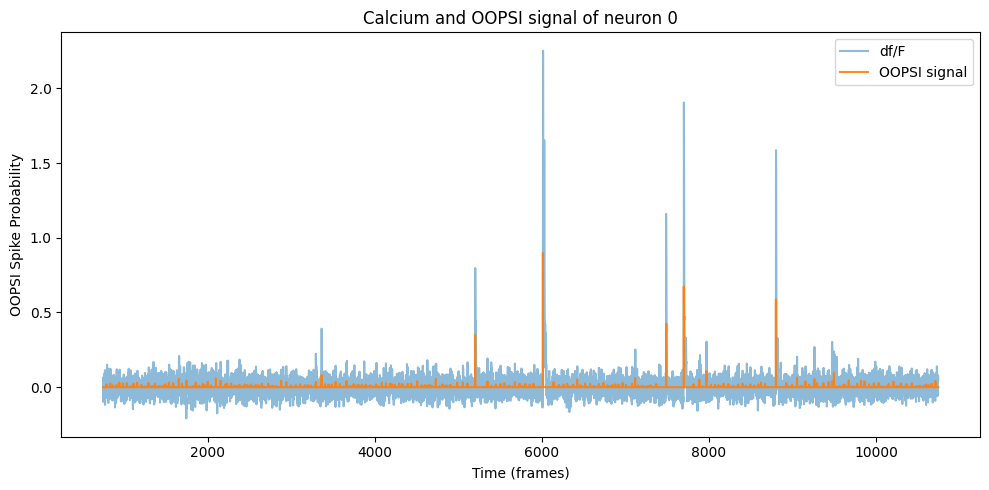

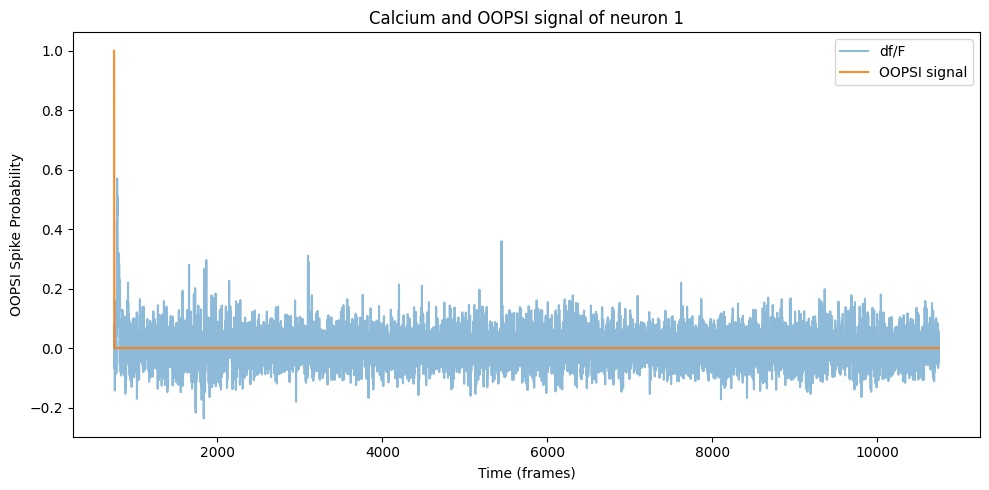

In [ ]:
plot_lim = 10000  # number of frames to show

for i, neuron in enumerate(df_raw.columns[0:2]):
    plt.figure(figsize=(10, 5))

    # plot raw trace
    plt.plot(
        df_raw.index.get_level_values("frame")[:plot_lim],
        df_raw[neuron].values[:plot_lim],
        alpha=0.5,
        label="df/F",
    )

    # plot OOPSI raw trace
    plt.plot(
        df_raw.index.get_level_values("frame")[:plot_lim],
        df_oopsi[neuron][:plot_lim],
        alpha=0.9,
        label="OOPSI signal",
    )

    plt.title(f"Calcium and OOPSI signal of neuron {neuron}")
    plt.xlabel("Time (frames)")
    plt.ylabel("OOPSI Spike Probability")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2.2 Spike Inference with OASIS

For Oasis we use the raw data as it performs better on the raw data than on the filtered data. However, we are also performing a parameter search to find the best parameters for the spike inference. Most of the code is adapted from the Oasis documentation.

Best parameters for each neuron:
{0: (np.float64(0.1), np.float64(0.1)), 1: (np.float64(0.1), np.float64(0.4)), 2: (np.float64(0.1), np.float64(0.30000000000000004)), 3: (np.float64(0.1), np.float64(0.5)), 4: (np.float64(0.1), np.float64(0.1)), 5: (np.float64(0.1), np.float64(0.1)), 6: (np.float64(0.1), np.float64(0.1)), 7: (np.float64(0.1), np.float64(0.6)), 8: (np.float64(0.1), np.float64(0.1)), 9: (np.float64(0.1), np.float64(0.1)), 10: (np.float64(0.1), np.float64(0.1)), 11: (np.float64(0.1), np.float64(0.1)), 12: (np.float64(0.1), np.float64(0.1)), 13: (np.float64(0.1), np.float64(0.6)), 14: (np.float64(0.1), np.float64(0.4)), 15: (np.float64(0.1), np.float64(0.1)), 16: (np.float64(0.1), np.float64(0.5)), 17: (np.float64(0.1), np.float64(0.1)), 18: (np.float64(0.1), np.float64(0.1)), 19: (np.float64(0.1), np.float64(0.1)), 20: (np.float64(0.1), np.float64(0.1)), 21: (np.float64(0.1), np.float64(0.1)), 22: (np.float64(0.1), np.float64(0.1)), 23: (np.float64(0.1), np.float64(0.1)), 

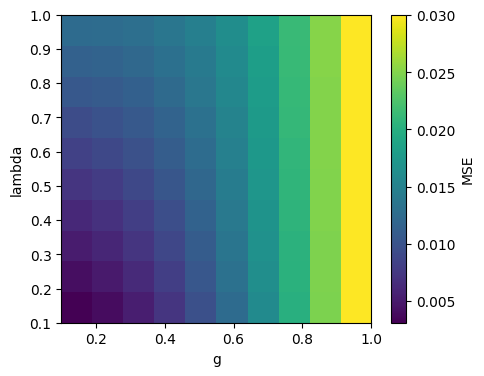

In [ ]:
determine_parameters = True

# parameter search space
lam_values = np.linspace(0.1, 1.0, 10)
g_values = np.linspace(0.1, 1.0, 10)

if determine_parameters:
    # evaluate the performance of deconvolution for different parameter combinations
    def evaluate_performance(true_signal, inferred_signal):
        mse = np.mean((true_signal - inferred_signal) ** 2)
        return mse

    # grid search
    best_params = {}
    best_performance = {}
    performance_grid = np.zeros((len(lam_values), len(g_values)))

    for neuron in df_raw.columns:
        best_mse = float("inf")
        best_lam = None
        best_g = None

        for lam_i, lam in enumerate(lam_values):
            for gi, g in enumerate(g_values):
                try:
                    # convert trace to float64 for oasisAR1 compatibility
                    trace = df_raw[neuron].values.astype(np.float64)
                    inferred_signal = oasisAR1(trace, g, lam)[1]
                    mse = evaluate_performance(trace, inferred_signal)
                    performance_grid[lam_i, gi] += mse
                except Exception as e:
                    print(f"An error occurred: {e}")
                    continue

                if mse < best_mse:
                    best_mse = mse
                    best_lam = lam
                    best_g = g

        if best_lam is not None and best_g is not None:
            best_params[neuron] = (best_lam, best_g)
            best_performance[neuron] = best_mse
        else:
            print(f"Skipping neuron {neuron} due to invalid parameters.")

    print("Best parameters for each neuron:")
    print(best_params)
    # ensure best_params and best_performance are not empty before calculating averages
    if best_params and best_performance:
        print("Best parameters averaged over all neurons:")
        print(np.mean(list(best_params.values()), axis=0))
        print("Best performance averaged over all neurons:")
        print(np.mean(list(best_performance.values())))
    else:
        print("No valid parameters found for any neuron.")
    print("Best parameters averaged over all neurons:")
    print(np.mean(list(best_params.values()), axis=0))
    print("Best performance averaged over all neurons:")
    print(np.mean(list(best_performance.values())))

    # average the performance across all neurons
    performance_grid /= len(df_raw.columns)

    # save performance grid as .npy file
    np.save("performance_grid.npy", performance_grid)

else:
    # load performance grid
    performance_grid = np.load("performance_grid.npy")

# plot performance grid
plt.figure(figsize=(5, 4))
plt.imshow(
    performance_grid,
    origin="lower",
    aspect="auto",
    extent=[g_values[0], g_values[-1], lam_values[0], lam_values[-1]],
)
plt.colorbar(label="MSE")
plt.xlabel("g")
plt.ylabel("lambda")
plt.show()

We let OASIS run on the preprocessed and raw data to infer spikes and we will compare their performance.

In [ ]:
determine_parameters = False  # set to True if you want to run the grid search
# set best parameters from grid search (or manually)
if determine_parameters:
    best_g = np.mean(list(best_params.values()), axis=0)[1]
    best_lam = np.mean(list(best_params.values()), axis=0)[0]
else:
    best_g = 0.2
    best_lam = 0.2


def apply_oasis(group):
    """
    Apply the OASIS algorithm to the group of traces.

    Parameters:
    - group: DataFrame with raw traces

    Returns: Series with deconvolved traces
    """
    trace = group.values.copy().astype(
        np.float64
    )  # ensure trace is float64 for Cython compatibility
    c, s = oasisAR1(trace, g=best_g, lam=best_lam)
    return pd.Series(s, index=group.index.get_level_values("frame"))


df_oasis = (
    df_raw.stack("neuron")
    .groupby(["neuron", "epoch"])
    .apply(apply_oasis)
    .unstack("neuron")
)
df_oasis

neuron        0    1    2    3    4    5    6    7         8    9    ...  96   \
epoch frame                                                          ...        
0     747     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  ...  0.0   
      748     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  ...  0.0   
      749     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  ...  0.0   
      750     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  ...  0.0   
      751     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  ...  0.0   
...           ...  ...  ...  ...  ...  ...  ...  ...       ...  ...  ...  ...   
2     115211  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.552046  0.0  ...  0.0   
      115212  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.884119  0.0  ...  0.0   
      115213  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.659718  0.0  ...  0.0   
      115214  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.491494  0.0  ...  0.0   
      115215  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.557120  0.0  ...  0.0   

neuron        97   98   99   100  101  102  103       104  105  
epoch frame                                                     
0     747     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
      748     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.014455  0.0  
      749     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
      750     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
      751     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
...           ...  ...  ...  ...  ...  ...  ...       ...  ...  
2     115211  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
      115212  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
      115213  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
      115214  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  
      115215  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  

[56615 rows x 106 columns]

In [ ]:
df_oasis_filtered = (
    df_preprocessed.stack("neuron")
    .groupby(["neuron", "epoch"])
    .apply(apply_oasis)
    .unstack("neuron")
)
df_oasis_filtered

neuron             0         1         2         3         4         5    \
epoch frame                                                                
0     747     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
      748     0.034091  0.000000  0.039426  0.000000  0.051997  0.000000   
      749     0.032398  0.000000  0.044543  0.004982  0.046639  0.000000   
      750     0.030606  0.000000  0.049571  0.083213  0.041265  0.000000   
      751     0.028728  0.000000  0.054481  0.143925  0.035900  0.000000   
...                ...       ...       ...       ...       ...       ...   
2     115211  0.000000  0.473691  0.040967  0.024227  0.071706  0.204432   
      115212  0.000000  0.475116  0.039715  0.021955  0.071518  0.203079   
      115213  0.000000  0.476227  0.038600  0.019961  0.071351  0.201893   
      115214  0.000000  0.477074  0.036999  0.013768  0.071207  0.200869   
      115215  0.000000  0.437703  0.000000  0.000000  0.031084  0.160001   

neuron             6         7         8         9    ...       96        97   \
epoch frame                                           ...                       
0     747     0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.000000   
      748     0.000000  0.130868  0.000000  0.024657  ...  0.059695  0.000000   
      749     0.000000  0.131733  0.000000  0.019064  ...  0.060799  0.000000   
      750     0.000000  0.132500  0.000000  0.013727  ...  0.062057  0.000000   
      751     0.000000  0.133177  0.000000  0.008661  ...  0.063453  0.000000   
...                ...       ...       ...       ...  ...       ...       ...   
2     115211  0.016670  0.121221  0.372008  0.109216  ...  0.000000  0.089549   
      115212  0.014716  0.120373  0.375277  0.109727  ...  0.000000  0.090329   
      115213  0.013039  0.119666  0.378017  0.110160  ...  0.000000  0.090984   
      115214  0.005935  0.119088  0.380277  0.110521  ...  0.000000  0.091525   
      115215  0.000000  0.078623  0.342110  0.070818  ...  0.000000  0.051963   

neuron             98        99        100       101       102       103  \
epoch frame                                                                
0     747     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
      748     0.000000  0.422626  0.000000  0.121020  0.326960  0.000000   
      749     0.000000  0.390861  0.000000  0.122701  0.311532  0.000000   
      750     0.000000  0.359667  0.000670  0.124193  0.296351  0.000000   
      751     0.000000  0.329159  0.002627  0.125468  0.281486  0.018283   
...                ...       ...       ...       ...       ...       ...   
2     115211  0.020001  0.211703  0.000000  0.054997  0.000000  0.228763   
      115212  0.020173  0.213545  0.000000  0.054876  0.000000  0.229119   
      115213  0.020328  0.215139  0.000000  0.054763  0.000000  0.229422   
      115214  0.016735  0.216498  0.000000  0.054661  0.000000  0.229678   
      115215  0.000000  0.177638  0.000000  0.014570  0.000000  0.189888   

neuron             104       105  
epoch frame                       
0     747     0.000000  0.000000  
      748     0.026104  0.360001  
      749     0.025981  0.366569  
      750     0.025806  0.372974  
      751     0.025577  0.379140  
...                ...       ...  
2     115211  0.000000  0.071626  
      115212  0.000000  0.071477  
      115213  0.000000  0.071362  
      115214  0.000000  0.071275  
      115215  0.000000  0.031212  

[56615 rows x 106 columns]

As indicated by our parameter search, the best parameters for OASIS are a decay factor of 0.2 and a regularization parameter of 0.2. We will use these parameters to infer spikes from the calcium data. We could use even a lower regularization parameter, but we found that the spikes are not as well separated from the noise and the inference is not as reliable. We will use these parameters to infer spikes from the calcium data.

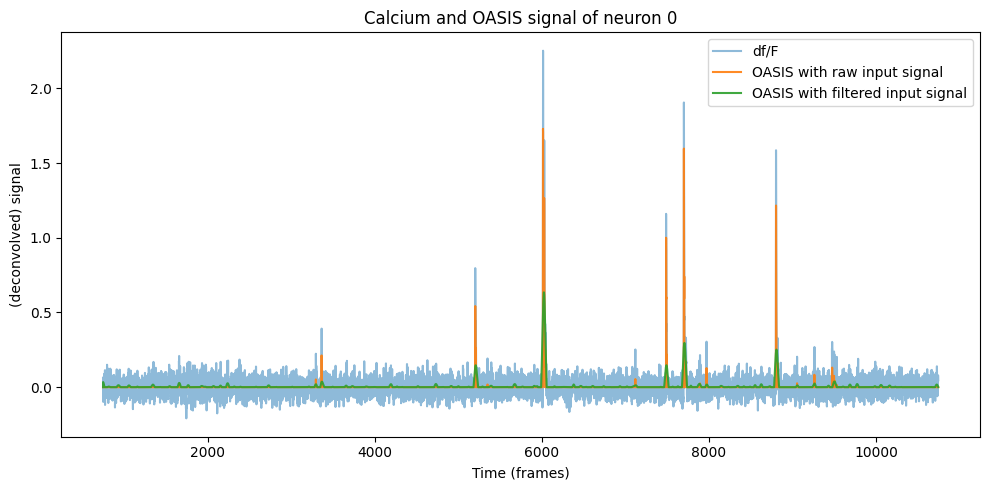

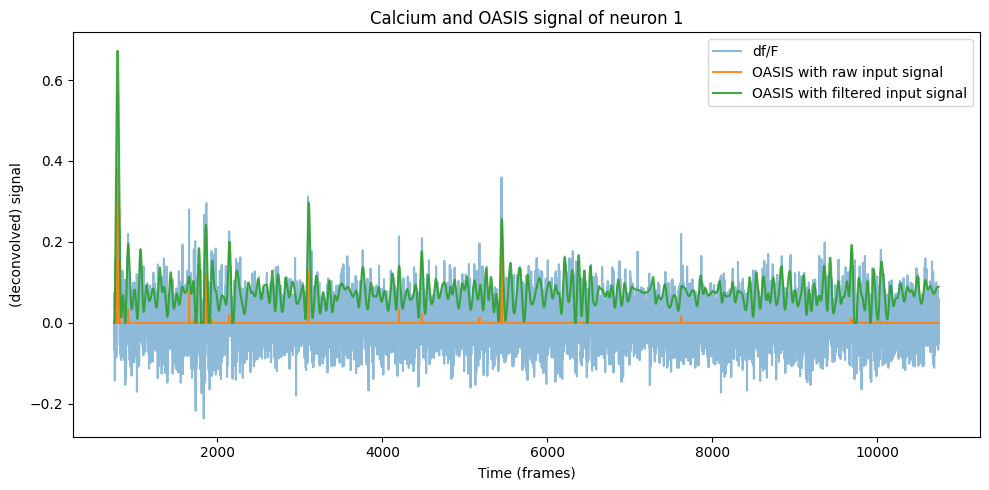

In [ ]:
plot_lim = 10000  # number of frames to show

for i, neuron in enumerate(df_raw.columns[0:2]):
    plt.figure(figsize=(10, 5))

    # plot raw trace
    plt.plot(
        df_raw.index.get_level_values("frame")[:plot_lim],
        df_raw[neuron].values[:plot_lim],
        alpha=0.5,
        label="df/F",
    )

    # plot OASIS raw trace
    plt.plot(
        df_raw.index.get_level_values("frame")[:plot_lim],
        df_oasis[neuron][:plot_lim],
        alpha=0.9,
        label="OASIS with raw input signal",
    )
    # plot OASIS filtered trace
    plt.plot(
        df_raw.index.get_level_values("frame")[:plot_lim],
        df_oasis_filtered[neuron][:plot_lim],
        alpha=0.9,
        label="OASIS with filtered input signal",
    )

    plt.title(f"Calcium and OASIS signal of neuron {neuron}")
    plt.xlabel("Time (frames)")
    plt.ylabel("(deconvolved) signal")
    plt.legend()
    plt.tight_layout()
    plt.show()

Interestingly, the spike inference with OASIS on the preprocessed data does not work as well as on the raw data. The inference seems to be a lot more noisy. As we do not have ground truth data for the spikes, we cannot compare the performance of the two methods quantitatively. However, we can visually inspect the results and see which method seems to perform better. Based on visual inspection, the OASIS inference on the raw data seems to be more reliable and less noisy than the OASIS inference on the preprocessed data. However, the performance of the algorithm also differs from cell to cell and is influenced by the signal to noise ratio.

### 2.3 Compare OOPSI and OASIS
OOPSI gives us spiking probility estimates and OASIS gives us discrete estimated calcium signals. What does a comparison look like?


Text(0.5, 0.98, 'Comparison of OOPSI and OASIS')

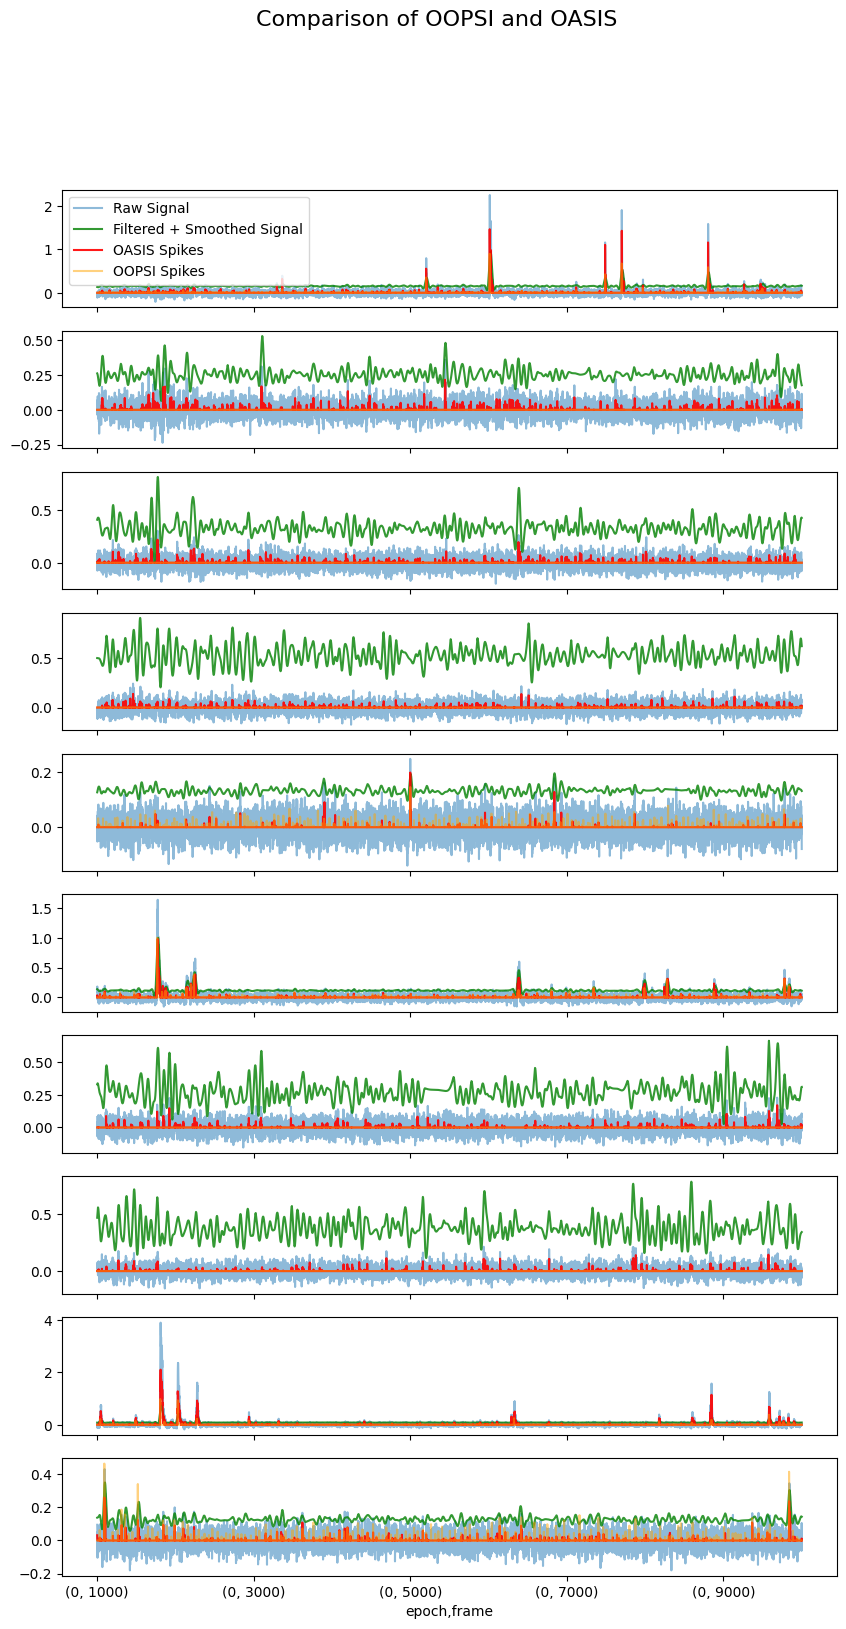

In [ ]:
# plot raw and filtered signal epoch 1 of neuron 1, 15 and 30
neuron_indices = range(0, 10)  # Neuron indices to plot
fig, axes = plt.subplots(len(neuron_indices), 1, figsize=(10, 18), sharex=True)

interval = slice(1000, 10000)  # frames to plot

for i, neuron in enumerate(neuron_indices):
    ax = axes[i]
    df_raw.loc[(0, interval), neuron].plot(ax=ax, label="Raw Signal", alpha=0.5)

    df_preprocessed.loc[(0, interval), neuron].plot(
        ax=ax, label="Filtered + Smoothed Signal", color="green", alpha=0.8
    )
    df_oasis.loc[(0, interval), neuron].plot(
        ax=ax, label="OASIS Spikes", color="red", alpha=0.9
    )
    df_oopsi.loc[(0, interval), neuron].plot(
        ax=ax, label="OOPSI Spikes", color="orange", alpha=0.5
    )
    if i == 0:
        # outside plot
        ax.legend()

# set title for the entire figure
fig.suptitle("Comparison of OOPSI and OASIS", fontsize=16)

### 2.4 How do we interpret OOPSI and OASIS results?

OOPSI gives us spiking probility estimates and OASIS gives us discrete estimated calcium signals. How do we compare and interpret these results?

Distribution of OOPSI spikes:

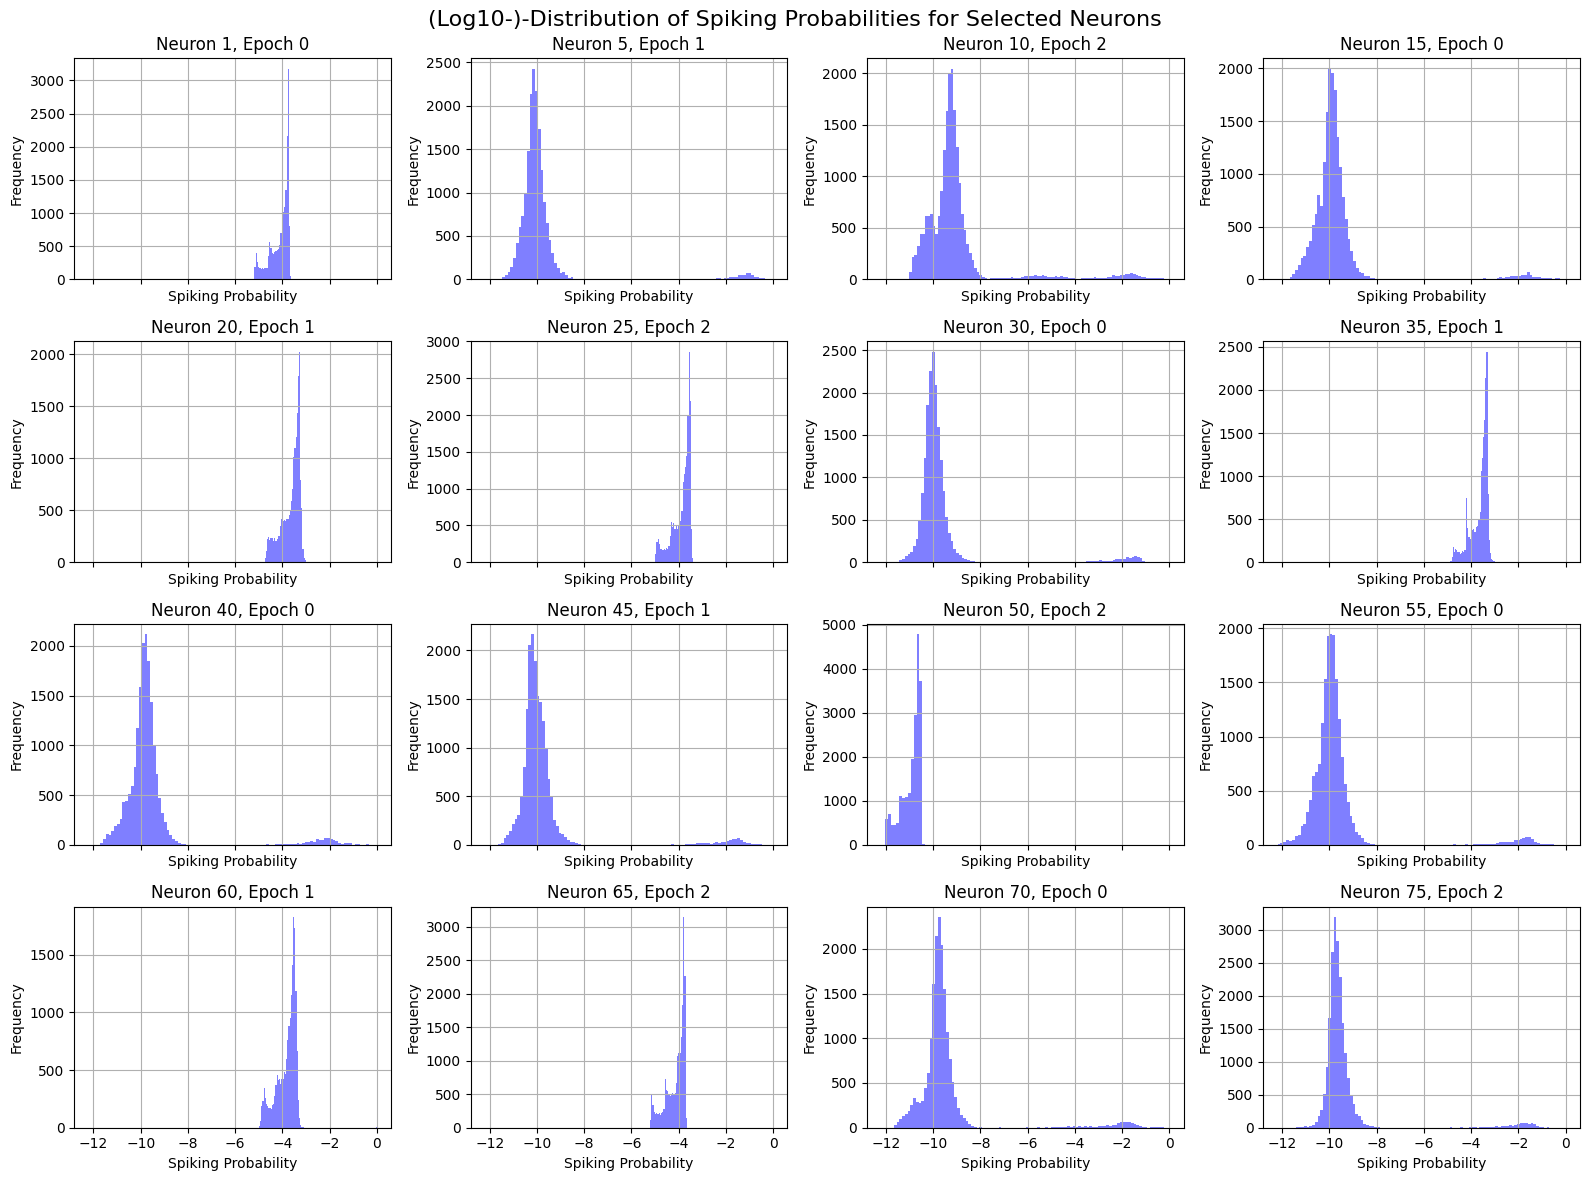

In [ ]:
# Select 16 neuron indices and corresponding epochs (choose any for demonstration)
neuron_indices = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
epoch_indices = [0, 1, 2, 0, 1, 2, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2]
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
axes = axes.flatten()
for i, (neuron, epoch) in enumerate(zip(neuron_indices, epoch_indices)):
    ax = axes[i]
    np.log10(df_oopsi.loc[(epoch, slice(None)), neuron]).hist(
        bins=100, ax=ax, color="blue", alpha=0.5
    )
    ax.set_title(f"Neuron {neuron}, Epoch {epoch}")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Spiking Probability")


fig.suptitle(
    "(Log10-)-Distribution of Spiking Probabilities for Selected Neurons",
    fontsize=16,
)
fig.tight_layout()

PLACEHOLDER: explain thresholding and how we can use it to detect spikes in the OOPSI data.

Distribution of OASIS spikes:

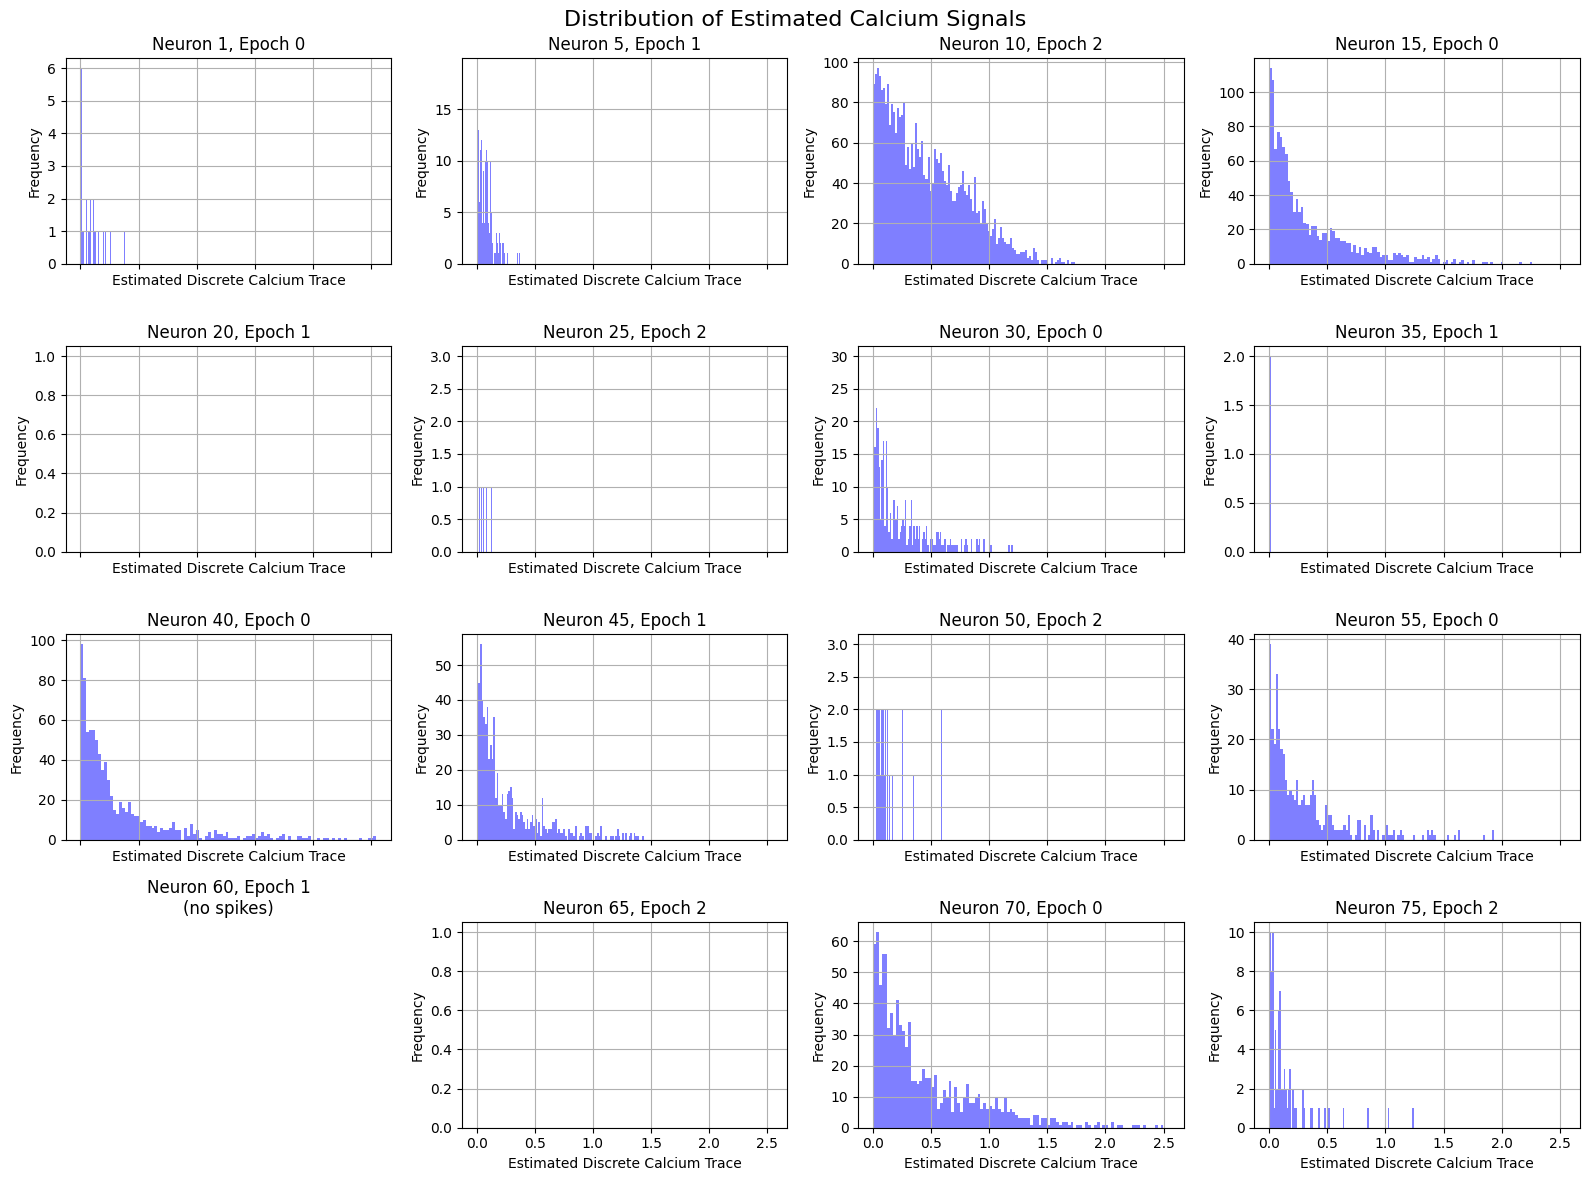

In [ ]:
# plot histograms with threshold overlay
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, (neuron, epoch) in enumerate(zip(neuron_indices, epoch_indices)):
    ax = axes[i]
    probs = df_oasis.loc[(epoch, slice(None)), neuron]
    nonzero_probs = probs[probs > 1e-5]

    if len(nonzero_probs) > 0:
        nonzero_probs.hist(bins=100, ax=ax, color="blue", alpha=0.5)
        ax.set_title(f"Neuron {neuron}, Epoch {epoch}")
        ax.set_xlabel("Estimated Discrete Calcium Trace")
        ax.set_ylabel("Frequency")
    else:
        ax.set_title(f"Neuron {neuron}, Epoch {epoch}\n(no spikes)")
        ax.axis("off")

fig.suptitle("Distribution of Estimated Calcium Signals", fontsize=16)
fig.tight_layout()

## 3 Tuning Functions

We now extract only the data for the stimulus we are interested in and based on the vonMises and Tuning function from Coding Lab 4 we implement the Tuning function fitting.

The experiment consists of trials, with varying frequency and direction of the drifting grating stimuli. `stim_table` contains the parameters of the stimulus (e.g. frequency, direction, etc.) and start and end of each trial.

To facilitate trial based analysis, we cut out data accordingly:

In [ ]:
def extract_drifting_grating_trials(trials, df):
    """
    Extract trials corresponding to drifting grating stimuli and organize them into a DataFrame.

    Parameters:
    - trials: DataFrame containing trial metadata (e.g., start, end, frequency, direction, etc.)
    - df: DataFrame containing the neural activity data (e.g., df/F values)

    Returns:
    - DataFrame containing the extracted trials with metadata
    """

    def is_drifting_grating(start, end):
        """
        Check if the given start and end times correspond to a drifting grating stimulus.

        Parameters:
        - start: start time of the trial
        - end: end time of the trial

        Returns:
        - bool: True if the trial is a drifting grating stimulus, False otherwise
        """
        return (
            ((start > 747) and (end < 18775))
            or ((start > 48602) and (end < 66630))
            or ((start > 94659) and (end < 115215))
        )

    records = []
    for i, row in trials.iterrows():
        # Check if trial is a drifting grating stimulus
        if not is_drifting_grating(row.start, row.end):
            continue
        # Get all neurons in this epoch
        trial_df = df.loc[pd.IndexSlice[:, row.start : row.end], :]
        trial_df.insert(0, "trial", i)
        trial_df.insert(0, "freq", row.frequency)
        trial_df.insert(0, "dir", row.direction)
        trial_df.insert(0, "blank_sweep", row.blank_sweep)
        # Add trial number as index
        trial_df.reset_index(inplace=True, drop=False)
        trial_df.set_index(
            ["epoch", "trial", "frame", "freq", "dir", "blank_sweep"], inplace=True
        )
        # Add to records
        records.append(trial_df)
    # Create DataFrame from records
    return pd.concat(records, axis=0)


df_oasis_trials = extract_drifting_grating_trials(trials, df_oasis)
df_oasis_trials

neuron                                     0    1    2    3    4         5    \
epoch trial frame  freq dir   blank_sweep                                      
0     1     837    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            838    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            839    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            840    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            841    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.190108   
...                                        ...  ...  ...  ...  ...       ...   
2     596   115121 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            115122 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            115123 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            115124 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   
            115125 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.000000   

neuron                                     6    7    8    9    ...  96   97   \
epoch trial frame  freq dir   blank_sweep                      ...             
0     1     837    2.0  180.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            838    2.0  180.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            839    2.0  180.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            840    2.0  180.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            841    2.0  180.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
...                                        ...  ...  ...  ...  ...  ...  ...   
2     596   115121 4.0  270.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            115122 4.0  270.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            115123 4.0  270.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            115124 4.0  270.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   
            115125 4.0  270.0 0.0          0.0  0.0  0.0  0.0  ...  0.0  0.0   

neuron                                     98   99   100  101  102  103  104  \
epoch trial frame  freq dir   blank_sweep                                      
0     1     837    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            838    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            839    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            840    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            841    2.0  180.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
...                                        ...  ...  ...  ...  ...  ...  ...   
2     596   115121 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            115122 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            115123 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            115124 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   
            115125 4.0  270.0 0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0   

neuron                                     105  
epoch trial frame  freq dir   blank_sweep       
0     1     837    2.0  180.0 0.0          0.0  
            838    2.0  180.0 0.0          0.0  
            839    2.0  180.0 0.0          0.0  
            840    2.0  180.0 0.0          0.0  
            841    2.0  180.0 0.0          0.0  
...                                        ...  
2     596   115121 4.0  270.0 0.0          0.0  
            115122 4.0  270.0 0.0          0.0  
            115123 4.0  270.0 0.0          0.0  
            115124 4.0  270.0 0.0          0.0  
            115125 4.0  270.0 0.0          0.0  

[35931 rows x 106 columns]

In [ ]:
df_oopsi_trials = extract_drifting_grating_trials(trials, df_oopsi)
df_oopsi_trials

neuron                                              0         1         2    \
epoch trial frame  freq dir   blank_sweep                                     
0     1     837    2.0  180.0 0.0          3.383983e-11  0.000017  0.000002   
            838    2.0  180.0 0.0          6.478717e-11  0.000044  0.000002   
            839    2.0  180.0 0.0          7.476057e-11  0.000182  0.000001   
            840    2.0  180.0 0.0          1.199480e-10  0.000256  0.000003   
            841    2.0  180.0 0.0          1.254557e-10  0.000168  0.000002   
...                                                 ...       ...       ...   
2     596   115121 4.0  270.0 0.0          8.674585e-12  0.000635  0.000013   
            115122 4.0  270.0 0.0          7.780129e-12  0.000104  0.000056   
            115123 4.0  270.0 0.0          1.405647e-11  0.000144  0.000117   
            115124 4.0  270.0 0.0          3.326632e-12  0.000361  0.000038   
            115125 4.0  270.0 0.0          3.727692e-11  0.000576  0.000124   

neuron                                              3             4    \
epoch trial frame  freq dir   blank_sweep                               
0     1     837    2.0  180.0 0.0          7.530143e-04  3.066668e-10   
            838    2.0  180.0 0.0          8.894708e-04  6.267919e-11   
            839    2.0  180.0 0.0          8.220614e-05  6.503313e-11   
            840    2.0  180.0 0.0          7.484009e-04  6.751283e-11   
            841    2.0  180.0 0.0          5.673912e-04  4.043123e-11   
...                                                 ...           ...   
2     596   115121 4.0  270.0 0.0          3.572443e-11  2.277142e-10   
            115122 4.0  270.0 0.0          8.027675e-11  1.016592e-10   
            115123 4.0  270.0 0.0          2.816260e-11  1.112735e-10   
            115124 4.0  270.0 0.0          1.685173e-11  3.047476e-10   
            115125 4.0  270.0 0.0          4.893087e-11  3.286855e-10   

neuron                                              5             6    \
epoch trial frame  freq dir   blank_sweep                               
0     1     837    2.0  180.0 0.0          7.675643e-12  2.591821e-10   
            838    2.0  180.0 0.0          6.205712e-11  2.464084e-11   
            839    2.0  180.0 0.0          7.505657e-11  1.174008e-11   
            840    2.0  180.0 0.0          8.488668e-11  2.308089e-10   
            841    2.0  180.0 0.0          3.381532e-01  1.652755e-10   
...                                                 ...           ...   
2     596   115121 4.0  270.0 0.0          1.403555e-10  1.242807e-10   
            115122 4.0  270.0 0.0          1.225179e-10  1.135086e-10   
            115123 4.0  270.0 0.0          1.145750e-10  9.240634e-11   
            115124 4.0  270.0 0.0          1.677703e-10  1.366821e-10   
            115125 4.0  270.0 0.0          1.000374e-10  8.904823e-12   

neuron                                          7             8    \
epoch trial frame  freq dir   blank_sweep                           
0     1     837    2.0  180.0 0.0          0.000352  1.706645e-11   
            838    2.0  180.0 0.0          0.000135  1.747143e-11   
            839    2.0  180.0 0.0          0.000548  1.763406e-11   
            840    2.0  180.0 0.0          0.000071  1.850104e-11   
            841    2.0  180.0 0.0          0.000096  1.924365e-11   
...                                             ...           ...   
2     596   115121 4.0  270.0 0.0          0.000128  2.318663e-11   
            115122 4.0  270.0 0.0          0.000039  2.222360e-11   
            115123 4.0  270.0 0.0          0.000075  2.426316e-11   
            115124 4.0  270.0 0.0          0.000174  2.978082e-11   
            115125 4.0  270.0 0.0          0.000063  3.288525e-11   

neuron                                              9    ...           96   \
epoch trial frame  freq dir   blank_sweep                ...                 
0     1     837   

In [ ]:
# vonMises tuning curve estimation
def vonMises(
    theta: np.ndarray, alpha: float, kappa: float, ny: float, phi: float
) -> np.ndarray:
    """Evaluate the parametric von Mises tuning curve with parameters p at locations theta.
    θ: np.array, shape=(N, )
        Locations. The input unit is degree.

    α, κ, ν, ϕ : float
        Function parameters

    Return
    ------
    f: np.array, shape=(N, )
        Tuning curve.
    """

    theta, phi = np.deg2rad(theta), np.deg2rad(phi)

    return np.exp(
        alpha + kappa * (np.cos(2 * (theta - phi)) - 1) + ny * (np.cos(theta - phi) - 1)
    )


def tuningCurve(group, tuning_parameter=None):
    """Calculate tuning curve for a group of trials."""
    spike_counts = group.groupby(["trial", tuning_parameter]).sum()
    mean_counts = group.groupby(tuning_parameter).sum()

    α0 = np.log(np.max(mean_counts.values) + 1e-3)
    ϕ0 = mean_counts.idxmax()
    p0 = [α0, 1.0, 1.0, ϕ0]
    p, _ = opt.curve_fit(
        vonMises,
        spike_counts.index.get_level_values(tuning_parameter).values,
        spike_counts.values,
        p0=p0,
        maxfev=10000,
    )
    return pd.Series(p, index=["α", "κ", "ν", "ϕ"])

In [ ]:
# compute tuning curves for OOPSI data
df_tuning_curves_oopsi = (
    df_oopsi_trials.stack("neuron")
    .groupby("neuron")
    .apply(tuningCurve, "dir")
    .to_frame()
    .unstack(level=1)
)
# remove the first level of the index
df_tuning_curves_oopsi.columns = df_tuning_curves_oopsi.columns
df_tuning_curves_oopsi.columns.name = "parameter"
df_tuning_curves_oopsi

In [ ]:
df_tuning_curves_oopsi.columns = df_tuning_curves_oopsi.columns.droplevel(0)
df_tuning_curves_oopsi.columns

Index(['α', 'κ', 'ν', 'ϕ'], dtype='object')

In [ ]:
# compute tuning curves for OASIS data
df_tuning_curves_oasis = (
    df_oasis_trials.stack("neuron")
    .groupby("neuron")
    .apply(tuningCurve, "dir")
    .to_frame()
    .unstack(level=1)
)
# remove the first level of the index
df_tuning_curves_oasis.columns = df_tuning_curves_oasis.columns.droplevel(0)
df_tuning_curves_oasis.columns.name = "parameter"
df_tuning_curves_oasis

/var/folders/_w/fvv3yfg57mj4b3g4yftq72cr0000gn/T/ipykernel_32999/3477722901.py:33: OptimizeWarning: Covariance of the parameters could not be estimated
  p, _ = opt.curve_fit(


parameter,α,κ,ν,ϕ
neuron,,,,
0,-0.557440,1.831507,0.909680,256.926718
1,-4.907785,0.433972,0.581075,198.760793
2,-3.771713,1.409416,0.451536,-2.992667
3,-3.162657,3.684799,2.454273,45.478506
4,-1.785045,1.873446,1.889866,137.553142
...,...,...,...,...
101,-4.216765,1.070439,0.639884,5.039093
102,0.327230,3.204907,1.758417,52.815434
103,-70.388776,-702.507255,1836.181583,292.471400


In [ ]:
def plot_tuning_curves(df_trials, df_tuning_curves, num_neurons=4):
    """
    Plot tuning curves, spike counts, and mean counts per frequency for randomly selected neurons.

    Parameters:
    - df_trials: DataFrame containing trial data with spike counts and directions.
    - df_tuning_curves: DataFrame containing tuning curve parameters for neurons.
    - num_neurons: Number of neurons to randomly select for plotting.
    """
    neurons = random.sample(range(df_tuning_curves.shape[0]), num_neurons)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    for i, neuron in enumerate(neurons):
        ax = axes[i]
        theta = np.linspace(0, 360, 100)

        ax.plot(
            theta,
            vonMises(
                theta,
                df_tuning_curves.loc[neuron, "α"],
                df_tuning_curves.loc[neuron, "κ"],
                df_tuning_curves.loc[neuron, "ν"],
                df_tuning_curves.loc[neuron, "ϕ"],
            ),
            label="Von Mises Fit",
            color="orange",
            alpha=0.7,
        )
        # scatterplot spike counts for individual trials
        spike_counts = df_trials.loc[:, neuron].groupby(["trial", "dir"]).sum()
        ax.scatter(
            spike_counts.index.get_level_values("dir").values,
            spike_counts.values,
            label="Spike Counts",
            color="blue",
            alpha=0.5,
        )

        # plot mean counts per direction
        mean_counts = df_trials.loc[:, neuron].groupby(["dir"]).mean()
        ax.scatter(
            spike_counts.index.get_level_values("dir").unique(),
            mean_counts.values,
            label="Mean Count per Direction",
            color="red",
            alpha=0.5,
        )

        ax.set_title(f"Neuron {neuron}")
        ax.set_xlabel("Direction (degrees)")
        ax.set_ylabel("Spike Count")
        ax.legend()
    fig.tight_layout()

#### OOPSI Tuning Curves

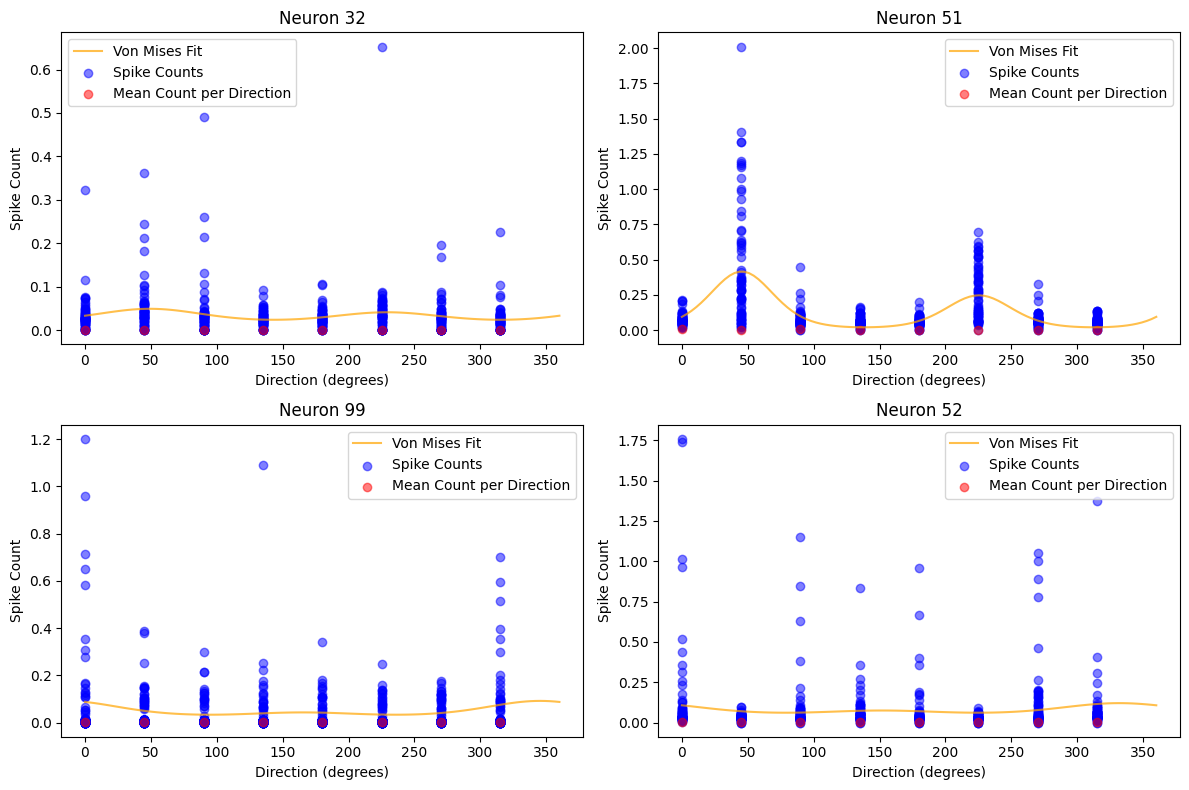

In [ ]:
plot_tuning_curves(df_oopsi_trials, df_tuning_curves_oopsi, num_neurons=4)

#### OASIS Tuning Curves

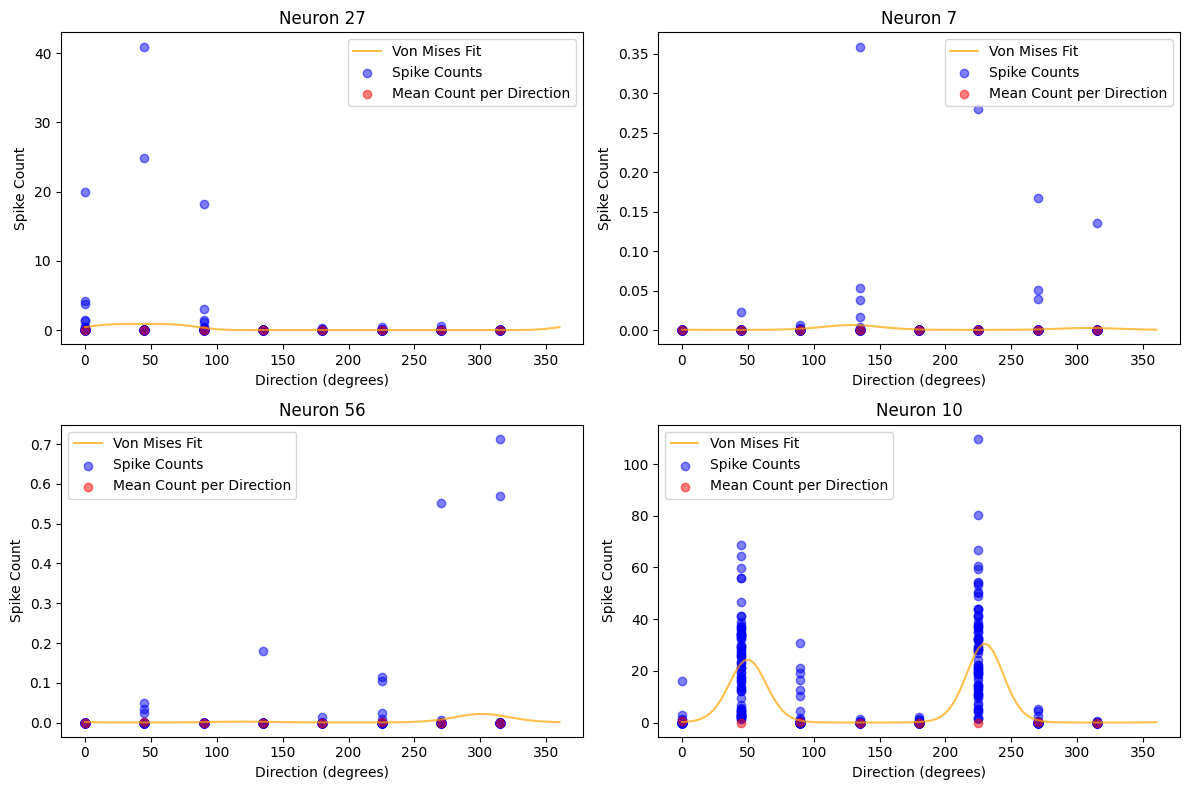

In [ ]:
plot_tuning_curves(df_oasis_trials, df_tuning_curves_oasis, num_neurons=4)

## 4 Statistical Testing
### 4.1 Permutation Test

We now implement - again based on the Coding Lab - a non-parametric permutation test for orientation, direction and frequency tuning. 

Direction tuning is calculated by looking at the first Fourier component, while orientation us the second FOurier component, because the first has a  a discretized oscillation with one cycle and the second a discretized oscillation with two cycles. 


In [ ]:
def testTuning(
    counts: np.ndarray,
    dirs: np.ndarray,
    psi: int = 1,
    niters: int = 1000,
    show: bool = False,
    random_seed: int = 2046,
) -> Tuple[float, float, np.ndarray]:
    """Permutation test for direction/orientation tuning."""
    unique_dirs = np.sort(np.unique(dirs))
    m = np.array([np.mean(counts[dirs == d]) for d in unique_dirs])
    v = np.exp(1j * psi * np.deg2rad(unique_dirs))
    q = np.dot(m, v)
    q_mag = np.abs(q)

    rng = np.random.default_rng(random_seed)
    qdistr = np.zeros(niters)
    for i in range(niters):
        shuffled_counts = rng.permutation(counts)
        m_perm = np.array([np.mean(shuffled_counts[dirs == d]) for d in unique_dirs])
        qdistr[i] = np.abs(np.dot(m_perm, v))

    p = np.mean(qdistr > q_mag)

    if show:
        import matplotlib.pyplot as plt

        plt.hist(qdistr, bins=30, alpha=0.7)
        plt.axvline(q_mag, color="r", linestyle="--")
        plt.title(f"ψ={psi} p={p:.4f}")
        plt.show()

    return p, q_mag, qdistr

In [ ]:
def compute_tuning_results(df_trials):
    """
    Compute tuning results for neurons based on direction and orientation and frequency.

    Parameters:
    - df_trials: DataFrame containing trial data with spike counts and directions.

    Returns:
    - DataFrame with tuning results including p-values, q-values, and significance.
    """
    results = []

    for neuron in tqdm(df_trials.columns):
        counts = df_trials[neuron].values
        dirs = df_trials.index.get_level_values("dir").values

        p_dir, q_dir, _ = testTuning(counts, dirs, psi=1, show=False)
        p_ori, q_ori, _ = testTuning(counts, dirs, psi=2, show=False)
        p_freq, q_freq, _ = testTuning(
            counts, df_trials.index.get_level_values("freq").values, psi=1, show=False
        )

        results.append(
            {
                "neuron": neuron,
                "p_dir": p_dir,
                "|q|_dir": q_dir,
                "p_ori": p_ori,
                "|q|_ori": q_ori,
                "sig_dir": p_dir < 0.05,
                "sig_ori": p_ori < 0.05,
                "p_freq": p_freq,
                "|q|_freq": q_freq,
                "sig_freq": p_freq < 0.05,
            }
        )

    # convert to DataFrame
    df_test_results = pd.DataFrame(results).set_index("neuron")
    return df_test_results

In [ ]:
# run the tuning test on OOPSI trials
df_test_results_oopsi = compute_tuning_results(df_oopsi_trials)
df_test_results_oopsi

100%|██████████| 106/106 [04:18<00:00,  2.44s/it]


,p_dir,|q|_dir,p_ori,|q|_ori,sig_dir,sig_ori,p_freq,|q|_freq,sig_freq
neuron,,,,,,,,,
0,0.383,0.000435,0.001,0.001057,False,True,0.250,0.002755,False
1,1.000,0.000193,0.000,0.000252,False,True,0.386,0.000872,False
2,0.000,0.000035,0.000,0.000019,True,True,1.000,0.000482,False
3,0.000,0.000034,0.000,0.000063,True,True,0.000,0.000731,True
4,0.174,0.000549,0.412,0.000402,False,False,0.995,0.004140,False
...,...,...,...,...,...,...,...,...,...
101,0.759,0.000132,0.521,0.000204,False,False,0.934,0.002913,False
102,0.000,0.002200,0.000,0.002554,True,True,1.000,0.006732,False
103,0.087,0.000260,0.497,0.000226,False,False,0.000,0.000717,True


In [ ]:
# run the tuning test on OASIS trials
df_test_results_oasis = compute_tuning_results(df_oasis_trials)
df_test_results_oasis

100%|██████████| 106/106 [06:25<00:00,  3.64s/it]


,p_dir,|q|_dir,p_ori,|q|_ori,sig_dir,sig_ori,p_freq,|q|_freq,sig_freq
neuron,,,,,,,,,
0,0.000,0.007793,0.000,0.009035,True,True,0.220,0.008733,False
1,0.058,0.000141,0.192,0.000110,False,False,0.950,0.000251,False
2,0.003,0.000277,0.000,0.000392,True,True,0.000,0.000551,True
3,0.000,0.000699,0.000,0.000616,True,True,0.000,0.000510,True
4,0.000,0.002876,0.000,0.002570,True,True,0.064,0.002274,False
...,...,...,...,...,...,...,...,...,...
101,0.224,0.000169,0.033,0.000245,False,True,0.000,0.000373,True
102,0.000,0.020210,0.000,0.019556,True,True,0.000,0.014878,True
103,0.001,0.000434,0.812,0.000089,True,False,0.511,0.000520,False


### 4.2 Spatial Structure of Neurons

First we create dataframe for each direction/orientation/frequency preferred neurons.

In [ ]:
# OASIS tuning test results

# filter for significant direction tuned neurons in df_tuning_curves from df_test_results
df_direction_tuned = df_test_results_oasis[df_test_results_oasis["sig_dir"]].index
df_tuning_curves_copy_dir_oasis = df.copy()
df_tuning_curves_copy_dir_oasis = df_tuning_curves_oasis.loc[df_direction_tuned, :]
print(df_tuning_curves_copy_dir_oasis)
print(len(df_tuning_curves_oasis), len(df_tuning_curves_copy_dir_oasis))

# filter for significant orientation tuned neurons in df_tuning_curves from df_test_results
df_orientation_tuned = df_test_results_oasis[df_test_results_oasis["sig_ori"]].index
df_tuning_curves_copy_ori_oasis = df_tuning_curves_oasis.copy()
df_tuning_curves_copy_ori_oasis = df_tuning_curves_copy_ori_oasis.loc[
    df_orientation_tuned, :
]
df_tuning_curves_copy_ori_oasis

# filter for significant frequency tuned neurons
df_frequency_tuned = df_test_results_oasis[df_test_results_oasis["sig_freq"]].index
df_tuning_curves_copy_freq_oasis = df_tuning_curves_oasis.copy()
df_tuning_curves_copy_freq_oasis = df_tuning_curves_copy_ori_oasis.loc[
    df_orientation_tuned, :
]
df_tuning_curves_copy_freq_oasis

parameter          α           κ            ν           ϕ
neuron                                                   
0          -0.557440    1.831507     0.909680  256.926718
2          -3.771713    1.409416     0.451536   -2.992667
3          -3.162657    3.684799     2.454273   45.478506
4          -1.785045    1.873446     1.889866  137.553142
5          -0.896946    0.780841     1.087281   84.797199
...              ...         ...          ...         ...
99         -1.281589    0.578995     1.394118  337.402513
100         0.011309    2.525593     0.050832  269.966189
102         0.327230    3.204907     1.758417   52.815434
103       -70.388776 -702.507255  1836.181583  292.471400
104        -0.734767   -0.073626     0.423914  211.155224

[89 rows x 4 columns]
106 89


parameter,α,κ,ν,ϕ
neuron,,,,
0,-0.557440,1.831507,0.909680,256.926718
2,-3.771713,1.409416,0.451536,-2.992667
3,-3.162657,3.684799,2.454273,45.478506
4,-1.785045,1.873446,1.889866,137.553142
6,-1.986813,6.428079,1.717857,314.218147
...,...,...,...,...
98,-1.963415,-2.200714,5.290829,306.793607
99,-1.281589,0.578995,1.394118,337.402513
100,0.011309,2.525593,0.050832,269.966189


In [ ]:
# OOPSI tuning test results

# filter for significant direction tuned neurons in df_tuning_curves from df_test_results
df_direction_tuned = df_test_results_oopsi[df_test_results_oopsi["sig_dir"]].index
df_tuning_curves_copy_dir_oopsi = df.copy()
df_tuning_curves_copy_dir_oopsi = df_tuning_curves_oopsi.loc[df_direction_tuned, :]
print(df_tuning_curves_copy_dir_oopsi)
print(len(df_tuning_curves_oopsi), len(df_tuning_curves_copy_dir_oopsi))

# filter for significant orientation tuned neurons in df_tuning_curves from df_test_results
df_orientation_tuned = df_test_results_oopsi[df_test_results_oopsi["sig_ori"]].index
df_tuning_curves_copy_ori_oopsi = df_tuning_curves_oopsi.copy()
df_tuning_curves_copy_ori_oopsi = df_tuning_curves_copy_ori_oopsi.loc[
    df_orientation_tuned, :
]
print(df_tuning_curves_copy_ori_oopsi)

# filter for significant frequency tuned neurons in df_tuning_curves from df_test_results
df_frequency_tuned = df_test_results_oopsi[df_test_results_oopsi["sig_freq"]].index
df_tuning_curves_copy_freq_oopsi = df_tuning_curves_oopsi.copy()
df_tuning_curves_copy_freq_oopsi = df_tuning_curves_copy_freq_oopsi.loc[
    df_frequency_tuned, :
]
df_tuning_curves_copy_freq_oopsi

               α         κ         ν           ϕ
neuron                                          
2      -5.008034  0.045165  0.086013  302.567304
3      -4.606826  0.107923  0.008551  203.388450
5      -1.539077  0.654492  0.158498   -2.227205
13     -4.392834  0.023228  0.026697  288.106534
17     -2.540794  0.336562  0.359934  311.976157
19     -1.024354  1.730164  0.175954  226.618625
25     -4.795721  0.006583  0.017692  114.558555
27     -2.142876  0.077073  0.339865   33.533348
28     -4.024799  0.540603  0.407674  226.816501
34     -4.720509 -0.011442  0.026175  317.167345
37     -4.349880  0.032849 -0.007313   19.682580
50     -2.766286  0.515941  0.309733   88.632616
51     -0.879104  1.392509  0.260853   45.375659
52     -2.117442  0.202646  0.239093  -28.110102
55     -1.369687  1.156287  0.207258    2.044345
56     -4.380561  0.005606  0.028682  312.543676
60     -4.704090  0.059379  0.043359  291.779685
70     -1.553124  0.901066  0.207721  180.812002
71     -3.504123  1.

,α,κ,ν,ϕ
neuron,,,,
2,-5.008034,0.045165,0.086013,302.567304
3,-4.606826,0.107923,0.008551,203.388450
5,-1.539077,0.654492,0.158498,-2.227205
13,-4.392834,0.023228,0.026697,288.106534
19,-1.024354,1.730164,0.175954,226.618625
37,-4.349880,0.032849,-0.007313,19.682580
50,-2.766286,0.515941,0.309733,88.632616
51,-0.879104,1.392509,0.260853,45.375659
52,-2.117442,0.202646,0.239093,-28.110102


We plot the structure of neurons based on "max_projection" in the data and then color circles at positions of the significnatly tuned cells in their position in "roi_mask". Each color represents what they are selective for. 

Note that the orientation and direction values are cyclic and therefore we use cyclic colorbars for both orientation and direction.

In [ ]:
def get_centroids_numpy(roi_masks):
    """Calculate centroids of ROIs from binary masks using numpy.
    Parameters:
    - roi_masks: list of binary masks (numpy arrays)
    """
    centroids = []
    for mask in roi_masks:
        y, x = np.nonzero(mask)
        if len(x) > 0 and len(y) > 0:
            cx = np.mean(x)
            cy = np.mean(y)
            centroids.append((cx, cy))
        else:
            centroids.append((np.nan, np.nan))
    return np.array(centroids)

/var/folders/ph/rzf8mr4124l1sb8_c8_qsrfr0000gn/T/ipykernel_28354/3349180523.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(


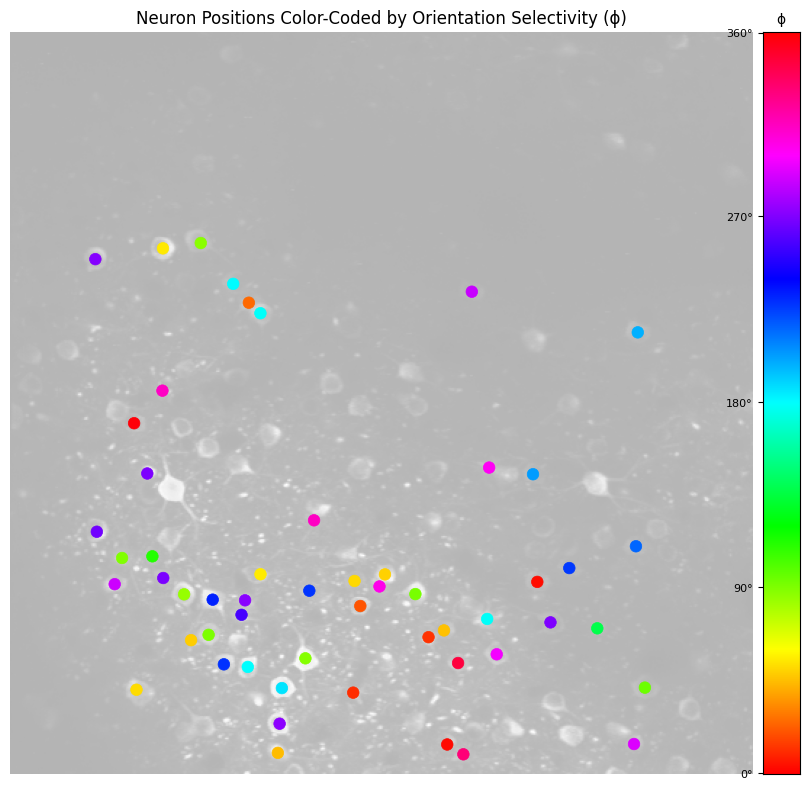

In [ ]:
roi_masks = data["roi_masks"]
centroids = get_centroids_numpy(roi_masks)

# Direction selectivity (ϕ)
phi = df_tuning_curves_copy_ori_oopsi["ϕ"].values
phi_norm = (phi % 360) / 360
colors = hsv_to_rgb(
    np.stack([phi_norm, np.ones_like(phi_norm), np.ones_like(phi_norm)], axis=1)
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(data["max_projection"], cmap="gray", alpha=0.3)

for (x, y), color in zip(centroids, colors):
    if not np.isnan(x) and not np.isnan(y):
        circle = plt.Circle(
            (x, y), radius=4, color=color, edgecolor="black", linewidth=0.5
        )
        ax.add_patch(circle)

ax.set_title("Neuron Positions Color-Coded by Orientation Selectivity (ϕ)")
ax.axis("off")

# Create  colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

hue = np.linspace(0, 1, 360).reshape(-1, 1)
hsv = np.repeat(hue, 10, axis=1)
rgb = hsv_to_rgb(np.stack([hsv, np.ones_like(hsv), np.ones_like(hsv)], axis=-1))
cax.imshow(rgb, aspect="auto", origin="lower")

cax.set_yticks([0, 90, 180, 270, 359])
cax.set_yticklabels(["0°", "90°", "180°", "270°", "360°"])
cax.set_xticks([])
cax.set_title("ϕ", fontsize=10)
cax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

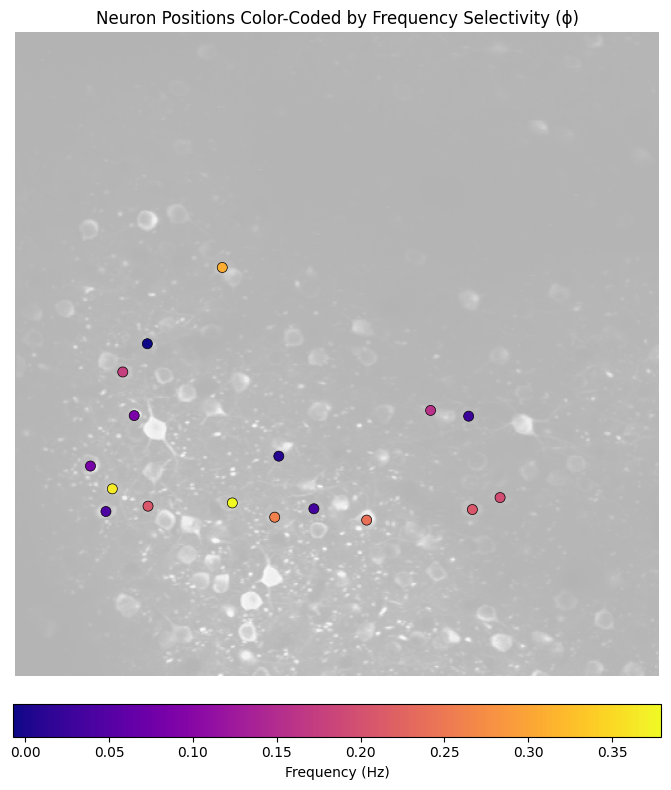

In [ ]:
freq = df_tuning_curves_copy_freq_oopsi["ν"].values  # Frequency values
freq_norm = (freq - freq.min()) / (freq.max() - freq.min())  # normalize to [0,1]
cmap = plt.cm.plasma  # Use same colormap for colorbar and scatter
colors = cmap(freq_norm)

# Frequency scale for colorbar
norm = Normalize(vmin=freq.min(), vmax=freq.max())
sm = ScalarMappable(norm=norm, cmap=cmap)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(data["max_projection"], cmap="gray", alpha=0.3)

for (x, y), color in zip(centroids, colors):
    if not np.isnan(x) and not np.isnan(y):
        circle = plt.Circle(
            (x, y), radius=4, facecolor=color, edgecolor="black", linewidth=0.5
        )
        ax.add_patch(circle)

ax.set_title("Neuron Positions Color-Coded by Frequency Selectivity (ϕ)")
ax.axis("off")

# Add colorbar to the same figure
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.046, pad=0.04)
cbar.set_label("Frequency (Hz)")

plt.tight_layout()
plt.show()

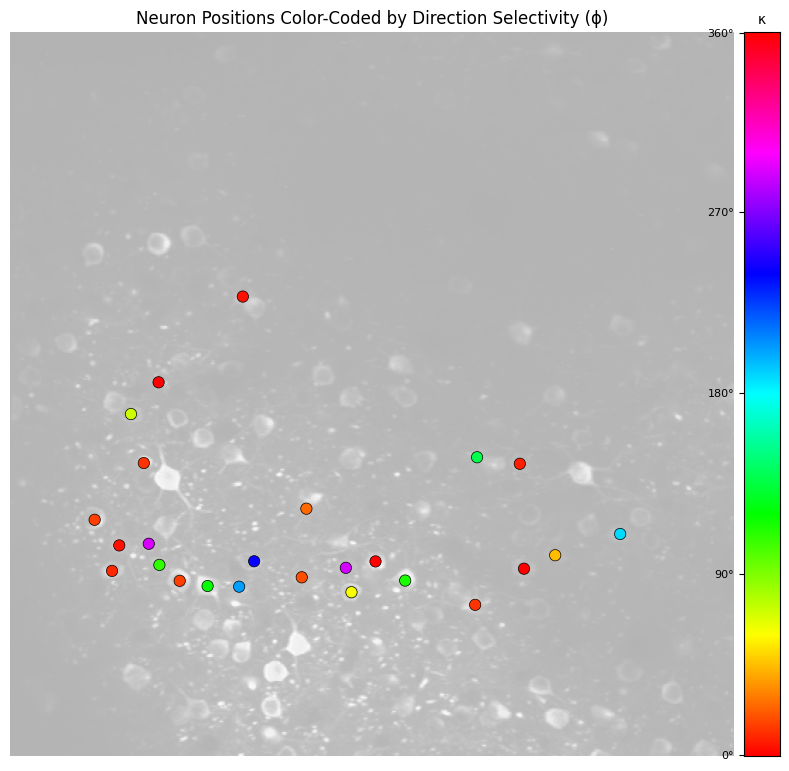

In [ ]:
# spatial structure for direction selectivity
directions = df_tuning_curves_copy_dir_oopsi["κ"].values
directions_norm = (directions - directions.min()) / (
    directions.max() - directions.min()
)
colors = hsv_to_rgb(
    np.stack(
        [
            directions_norm,
            np.ones_like(directions_norm),
            np.ones_like(directions_norm),
        ],
        axis=1,
    )
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(data["max_projection"], cmap="gray", alpha=0.3)
for (x, y), color in zip(centroids, colors):
    if not np.isnan(x) and not np.isnan(y):
        circle = plt.Circle(
            (x, y), radius=4, facecolor=color, edgecolor="black", linewidth=0.5
        )
        ax.add_patch(circle)
ax.set_title("Neuron Positions Color-Coded by Direction Selectivity (ϕ)")
ax.axis("off")
# Create colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
hue = np.linspace(0, 1, 360).reshape(-1, 1)
hsv = np.repeat(hue, 10, axis=1)
rgb = hsv_to_rgb(np.stack([hsv, np.ones_like(hsv), np.ones_like(hsv)], axis=-1))
cax.imshow(rgb, aspect="auto", origin="lower")
cax.set_yticks([0, 90, 180, 270, 359])
cax.set_yticklabels(["0°", "90°", "180°", "270°", "360°"])
cax.set_xticks([])
cax.set_title("κ", fontsize=10)
cax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

Now we do the same for the OASIS data.

/var/folders/_w/fvv3yfg57mj4b3g4yftq72cr0000gn/T/ipykernel_32999/2970245927.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(


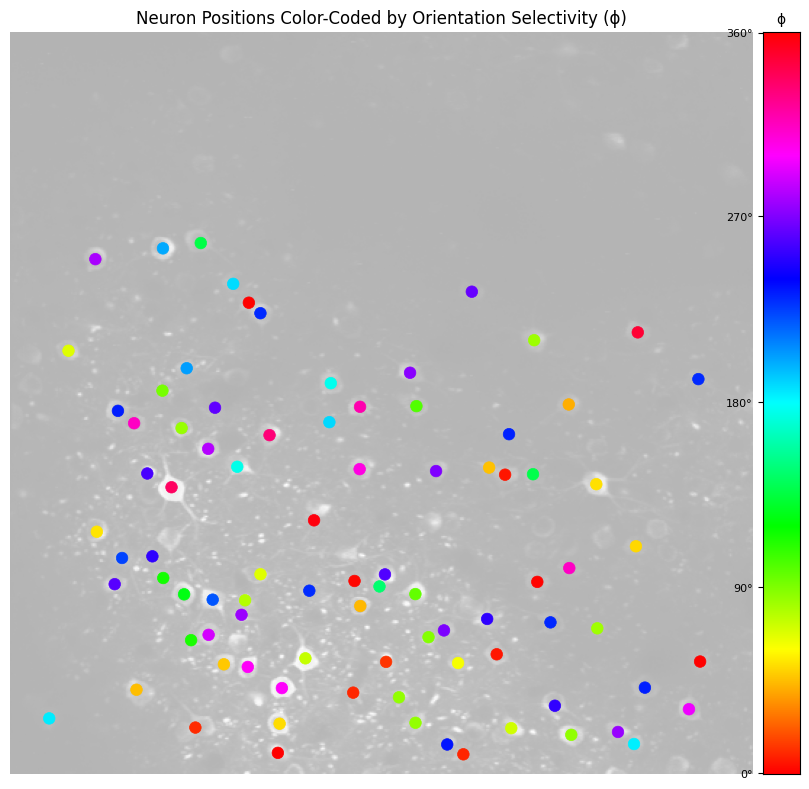

In [ ]:
roi_masks = data["roi_masks"]
centroids = get_centroids_numpy(roi_masks)

# Direction selectivity (ϕ)
phi = df_tuning_curves_copy_ori_oasis["ϕ"].values
phi_norm = (phi % 360) / 360
colors = hsv_to_rgb(
    np.stack([phi_norm, np.ones_like(phi_norm), np.ones_like(phi_norm)], axis=1)
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(data["max_projection"], cmap="gray", alpha=0.3)

for (x, y), color in zip(centroids, colors):
    if not np.isnan(x) and not np.isnan(y):
        circle = plt.Circle(
            (x, y), radius=4, color=color, edgecolor="black", linewidth=0.5
        )
        ax.add_patch(circle)

ax.set_title("Neuron Positions Color-Coded by Orientation Selectivity (ϕ)")
ax.axis("off")

# Create  colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

hue = np.linspace(0, 1, 360).reshape(-1, 1)
hsv = np.repeat(hue, 10, axis=1)
rgb = hsv_to_rgb(np.stack([hsv, np.ones_like(hsv), np.ones_like(hsv)], axis=-1))
cax.imshow(rgb, aspect="auto", origin="lower")

cax.set_yticks([0, 90, 180, 270, 359])
cax.set_yticklabels(["0°", "90°", "180°", "270°", "360°"])
cax.set_xticks([])
cax.set_title("ϕ", fontsize=10)
cax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

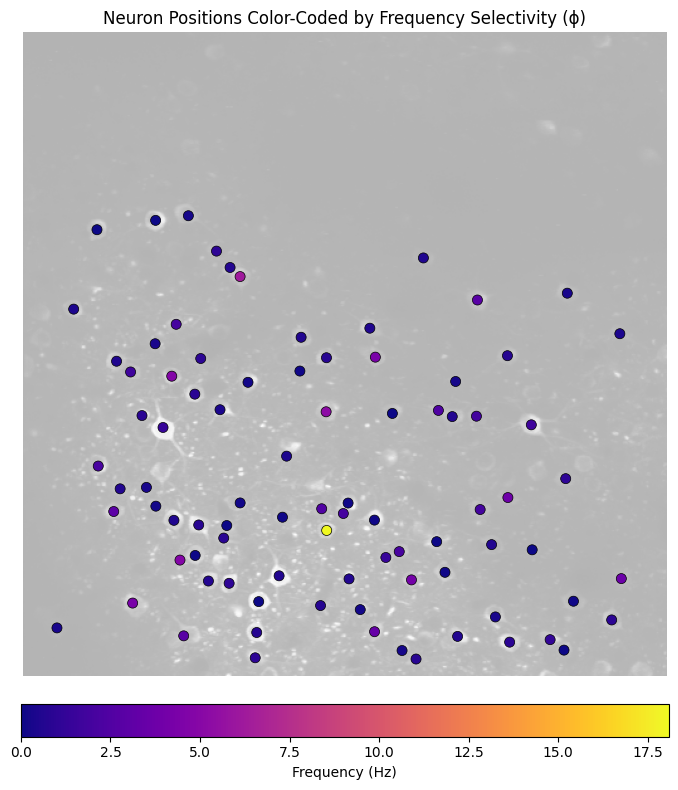

In [ ]:
# frequency tuned from OASIS
freq = df_tuning_curves_copy_freq_oasis["ν"].values  # Frequency values
freq_norm = (freq - freq.min()) / (freq.max() - freq.min())  # normalize to [0,1]
cmap = plt.cm.plasma  # Use same colormap for colorbar and scatter
colors = cmap(freq_norm)

# Frequency scale for colorbar
norm = Normalize(vmin=freq.min(), vmax=freq.max())
sm = ScalarMappable(norm=norm, cmap=cmap)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(data["max_projection"], cmap="gray", alpha=0.3)

for (x, y), color in zip(centroids, colors):
    if not np.isnan(x) and not np.isnan(y):
        circle = plt.Circle(
            (x, y), radius=4, facecolor=color, edgecolor="black", linewidth=0.5
        )
        ax.add_patch(circle)

ax.set_title("Neuron Positions Color-Coded by Frequency Selectivity (ϕ)")
ax.axis("off")

# Add colorbar to the same figure
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.046, pad=0.04)
cbar.set_label("Frequency (Hz)")

plt.tight_layout()
plt.show()

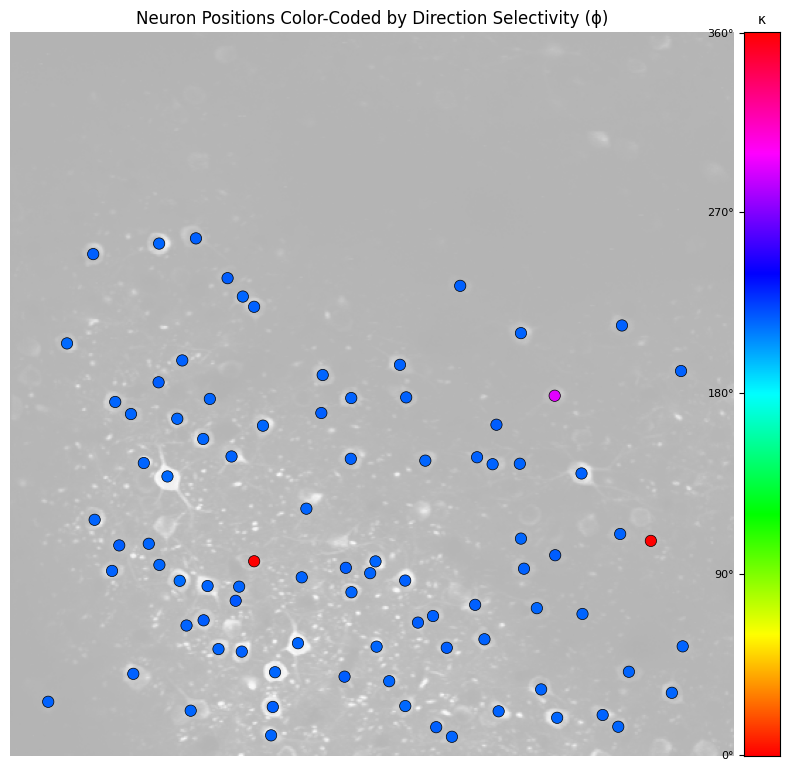

In [ ]:
# direction tuned from OASIS

directions = df_tuning_curves_copy_dir_oasis["κ"].values
directions_norm = (directions - directions.min()) / (
    directions.max() - directions.min()
)
colors = hsv_to_rgb(
    np.stack(
        [
            directions_norm,
            np.ones_like(directions_norm),
            np.ones_like(directions_norm),
        ],
        axis=1,
    )
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(data["max_projection"], cmap="gray", alpha=0.3)
for (x, y), color in zip(centroids, colors):
    if not np.isnan(x) and not np.isnan(y):
        circle = plt.Circle(
            (x, y), radius=4, facecolor=color, edgecolor="black", linewidth=0.5
        )
        ax.add_patch(circle)
ax.set_title("Neuron Positions Color-Coded by Direction Selectivity (ϕ)")
ax.axis("off")
# Create colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
hue = np.linspace(0, 1, 360).reshape(-1, 1)
hsv = np.repeat(hue, 10, axis=1)
rgb = hsv_to_rgb(np.stack([hsv, np.ones_like(hsv), np.ones_like(hsv)], axis=-1))
cax.imshow(rgb, aspect="auto", origin="lower")
cax.set_yticks([0, 90, 180, 270, 359])
cax.set_yticklabels(["0°", "90°", "180°", "270°", "360°"])
cax.set_xticks([])
cax.set_title("κ", fontsize=10)
cax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 5 Conclusion

Our goal was to analyzse the spatial structure of orientation, direction and frequency tuning of neurons.
We have results from two different methods, the Oopsi and OASIS toolbox. 

Observations about the spatial distribution:

- A big diversity of orientation preferences scattered throughout the tissue
- Most neurons show low frequency preferences (purple/blue colors)
- Moderate number of direction-selective neurons
- No obvious clustering or organization pattern - neurons with different orientation preferences appear intermixed

An explanation could be that rodent visual cortex shows more distributed rather than columnar functional architecture compared to humans.